## 1. Import Libraries
Import necessary libraries for data handling, dataset loading, and utility functions for the RAG pipeline.

In [1]:
import os
from datasets import load_dataset
import pandas as pd
import random
from collections import OrderedDict

# import flask_app
from utils2 import (
    suppress_subprocess_output,
)
from utils import (
    generate_with_multiple_input,
    generate_with_single_input,
    print_object_properties,
    display_widget
)

╭───────────────────────────────────────────── 🚀 New SDK Available ──────────────────────────────────────────────╮
│ Together Python SDK 2.0 is now available!                                                                       │
│                                                                                                                 │
│ Install the beta:                                                                                               │
│ pip install --pre together  or  uv add together --prerelease allow                                              │
│                                                                                                                 │
│ New SDK: ]8;id=674049;https://github.com/togethercomputer/together-py\https://github.com/togethercomputer/together-py]8;;\                                                        │
│ Migration guide: ]8;id=190196;https://docs.together.ai/docs/pythonv2-migration-guide\https://docs.together.ai/docs/pythonv2-migration-guide]8;;\                                         │
│                                                                                                                 │
│ This package will be maintained until January 2026.                                                             │
│ Set TOGETHER_NO_BANNER=1 to hide this message.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 2. Load Datasets
Load the Natural Questions (NQ) and HotpotQA datasets from Hugging Face for knowledge retrieval and evaluation.

In [2]:

# Configure HF cache location (change if needed)
os.environ['HF_DATASETS_CACHE'] = 'E:/huggingface_cache'  # adjust path if desired

# Load datasets with friendly messages
print("Loading datasets (may take a few minutes if not cached)...")
try:
    nq = load_dataset("nq_open")
    print(f"✓ 'nq_open' loaded. Splits: {list(nq.keys())}")
except Exception as e:
    raise RuntimeError(f"Failed to load 'nq_open': {e}")

try:
    hotpot = load_dataset("hotpot_qa", "distractor")
    print(f"✓ 'hotpot_qa' (distractor) loaded. Splits: {list(hotpot.keys())}")
except Exception as e:
    raise RuntimeError(f"Failed to load 'hotpot_qa': {e}")

# Print basic counts for quick awareness
print(f"NQ train examples: {len(nq['train'])}")
print(f"HotpotQA train examples: {len(hotpot['train'])}")


Loading datasets (may take a few minutes if not cached)...
✓ 'nq_open' loaded. Splits: ['train', 'validation']
✓ 'hotpot_qa' (distractor) loaded. Splits: ['train', 'validation']
NQ train examples: 87925
HotpotQA train examples: 90447


### Dataset Inspection
Convert datasets to Pandas DataFrames and inspect their structure and sample data.

In [3]:
# Convert dataset splits to pandas DataFrame for easier inspection
try:
    df = nq['train'].to_pandas()
    hp = hotpot['train'].to_pandas()
except Exception as e:
    raise RuntimeError(f"Failed to convert datasets to pandas DataFrame: {e}")

# Show structure and small sample to understand fields
print("\n== Dataset Quick Overview ==")
print(f"NQ DataFrame shape: {df.shape}")
print(f"NQ DataFrame columns: {df.columns.tolist()}")
print('\nSample (NQ):')
print(df.head(3).to_string(index=False))

print('\n--')
print(f"Hotpot DataFrame shape: {hp.shape}")
print(f"Hotpot DataFrame columns: {hp.columns.tolist()}")
print('\nSample (Hotpot):')
print(hp.head(3).to_string(index=False))
print(hp.info())


== Dataset Quick Overview ==
NQ DataFrame shape: (87925, 2)
NQ DataFrame columns: ['question', 'answer']

Sample (NQ):
                                        question                 answer
        where did they film hot tub time machine [Fernie Alpine Resort]
who has the right of way in international waters       [Neither vessel]
         who does annie work for attack on titan               [Marley]

--
Hotpot DataFrame shape: (90447, 7)
Hotpot DataFrame columns: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context']

Sample (Hotpot):
                      id                                                                                                                        question                  answer       type  level                                                                                            supporting_facts                                                                                                                                  

### NQ DATA

### Extract NQ Documents
Extract unique documents and Q&A pairs from the Natural Questions dataset with deduplication.

In [4]:
# Extract documents from NQ dataset (cleaner, deduplicated, informative)

MAX_EXAMPLES = 85000
print(f"Processing up to {MAX_EXAMPLES} NQ train examples...")

nq_documents = []
nq_qa_pairs = []

df = nq['train'].to_pandas()
for i, row in df.head(MAX_EXAMPLES).iterrows():
    question = row['question']
    answers = row['answer']

    # Skip if no answers
    if len(answers) == 0:
        continue

    # Normalize and collect answers as document candidates
    for ans in answers:
        if not isinstance(ans, str):
            continue
        text = ans.strip()
        if not text:
            continue
        nq_documents.append(text)

    nq_qa_pairs.append({
        'question': question,
        'answers': answers
    })

# Deduplicate while preserving order
nq_documents = list(OrderedDict.fromkeys(nq_documents))

print(f"✓ Extracted {len(nq_documents)} unique documents from {len(nq_qa_pairs)} NQ Q&A pairs")
# Show a small sample for verification
if nq_qa_pairs:
    print('\nSample NQ question:')
    print(nq_qa_pairs[0]['question'])
    print('\nSample NQ answers (first two):')
    print(nq_qa_pairs[0])


Processing up to 85000 NQ train examples...
✓ Extracted 56978 unique documents from 85000 NQ Q&A pairs

Sample NQ question:
where did they film hot tub time machine

Sample NQ answers (first two):
{'question': 'where did they film hot tub time machine', 'answers': array(['Fernie Alpine Resort'], dtype=object)}


### HP DATA

### Extract HotpotQA Documents
Extract documents from HotpotQA and save both datasets to disk in JSONL and Pickle formats.

In [5]:
# Extract documents from HotpotQA and save extracted data (documents + QA pairs)
import json
import pickle
from pathlib import Path

MAX_EXAMPLES_HP = 85000
print(f"\nProcessing up to {MAX_EXAMPLES_HP} HotpotQA train examples...")

hotpot_documents = []
hotpot_qa_pairs = []

for i, example in enumerate(hotpot['train'].select(range(min(MAX_EXAMPLES_HP, len(hotpot['train']))))):
    question = example.get('question', '')
    context = example.get('context', {})
    answer = example.get('answer', '')

    # Extract sentences from context if available
    if isinstance(context, dict) and 'sentences' in context:
        for sentence_list in context['sentences']:
            if isinstance(sentence_list, list):
                for s in sentence_list:
                    if isinstance(s, str) and s.strip():
                        hotpot_documents.append(s.strip())
    elif isinstance(context, str) and context.strip():
        for s in context.split('\n'):
            t = s.strip()
            if t:
                hotpot_documents.append(t)

    hotpot_qa_pairs.append({
        'question': question,
        'answer': answer,
        'type': example.get('type')
    })

# Deduplicate while preserving order
hotpot_documents = list(OrderedDict.fromkeys(hotpot_documents))

print(f"✓ Extracted {len(hotpot_documents)} unique HotpotQA documents from {len(hotpot_qa_pairs)} Q&A pairs")
if hotpot_qa_pairs:
    print('\nSample HotpotQA question:')
    print(hotpot_qa_pairs[0]['question'])
    print('\nSample HotpotQA answer:')
    print(hotpot_qa_pairs[0]['answer'])

# Save documents and QA pairs to disk for later RAG indexing
out_dir = Path('data')
out_dir.mkdir(exist_ok=True)

# JSONL documents include a small metadata tag to identify dataset
with open(out_dir / 'nq_documents.jsonl', 'w', encoding='utf-8') as f:
    for i, text in enumerate(nq_documents):
        json.dump({'id': f'nq_{i}', 'text': text, 'source': 'nq'}, f, ensure_ascii=False)
        f.write('\n')

with open(out_dir / 'hotpot_documents.jsonl', 'w', encoding='utf-8') as f:
    for i, text in enumerate(hotpot_documents):
        json.dump({'id': f'hotpot_{i}', 'text': text, 'source': 'hotpot'}, f, ensure_ascii=False)
        f.write('\n')

# Save QA pairs as pickle for quick reloading
with open(out_dir / 'nq_qa_pairs.pkl', 'wb') as f:
    pickle.dump(nq_qa_pairs, f)

with open(out_dir / 'hotpot_qa_pairs.pkl', 'wb') as f:
    pickle.dump(hotpot_qa_pairs, f)

print(f"Saved outputs to {out_dir.resolve()}")
print(f" - NQ docs: {len(nq_documents)}")
print(f" - Hotpot docs: {len(hotpot_documents)}")
print(f" - NQ QA pairs: {len(nq_qa_pairs)}")
print(f" - Hotpot QA pairs: {len(hotpot_qa_pairs)}")



Processing up to 85000 HotpotQA train examples...
✓ Extracted 1711467 unique HotpotQA documents from 85000 Q&A pairs

Sample HotpotQA question:
Which magazine was started first Arthur's Magazine or First for Women?

Sample HotpotQA answer:
Arthur's Magazine
Saved outputs to E:\DS Documents\Dissertation\Project\data
 - NQ docs: 56978
 - Hotpot docs: 1711467
 - NQ QA pairs: 85000
 - Hotpot QA pairs: 85000


### Normalize Answer Format
Convert all answers to strings for compatibility with the vector database.

In [6]:
# Convert answers lists to strings for Weaviate compatibility
for pair in nq_qa_pairs:
    if isinstance(pair['answers'], list):
        pair['answers'] = ', '.join(str(ans) for ans in pair['answers'] if ans)

for pair in hotpot_qa_pairs:
    # Hotpot answers are already strings, but ensure
    pair['answer'] = str(pair['answer'])

### Clean NQ Data
Clean and format NQ Q&A pairs, handling missing values and preparing for batch import.

In [7]:
# Clean and format the nq_qa_pairs for Weaviate batch import
cleaned_nq_data = []

for pair in nq_qa_pairs:
    # Get question and answers
    question = pair.get('question', '')
    answers = pair.get('answers', '')

    # Convert to string
    question = str(question) if question is not None else "No data provided"
    answers = str(answers) if answers is not None else "No data provided"

    # Handle lists in answers
    if isinstance(pair.get('answers'), list):
        answers = '; '.join(str(ans) for ans in pair['answers'] if ans is not None)

    # Replace empty or whitespace-only with placeholder
    if not question.strip():
        question = "No data provided"
    if not answers.strip():
        answers = "No data provided"

    # Skip if both are "No data provided"
    if question == "No data provided" and answers == "No data provided":
        continue

    cleaned_nq_data.append({
        'question': question,
        'answers': answers
    })

print(f"Cleaned data has {len(cleaned_nq_data)} records.")

Cleaned data has 85000 records.


### Clean HotpotQA Data
Clean and format HotpotQA pairs, ensuring all metadata fields are properly populated.

In [8]:
# Clean and format the hotpot_qa_pairs for Weaviate batch import
cleaned_hotpot_data = []

for pair in hotpot_qa_pairs:
    # Get question, answer, and type
    question = pair.get('question', '')
    answer = pair.get('answer', '')
    type_ = pair.get('type', '')

    # Convert to string
    question = str(question) if question is not None else "No data provided"
    answer = str(answer) if answer is not None else "No data provided"
    type_ = str(type_) if type_ is not None else "No data provided"

    # Replace empty or whitespace-only with placeholder
    if not question.strip():
        question = "No data provided"
    if not answer.strip():
        answer = "No data provided"
    if not type_.strip():
        type_ = "No data provided"

    # Skip if all are "No data provided"
    if question == "No data provided" and answer == "No data provided" and type_ == "No data provided":
        continue

    cleaned_hotpot_data.append({
        'question': question,
        'answer': answer,
        'type': type_
    })

print(f"Cleaned hotpot data has {len(cleaned_hotpot_data)} records.")

Cleaned hotpot data has 85000 records.


## 3. API Configuration
Load environment variables for Cohere, Gemini, OpenRouter, Hugging Face, Phoenix, and Weaviate APIs.

In [9]:
import os
from dotenv import load_dotenv

load_dotenv('API.env')

COHERE_API_KEY = os.getenv('COHERE_API_KEY')
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY')
HUGGINGFACE_API_KEY = os.getenv('HUGGINGFACE_API_KEY')
PHOENIX_API_KEY = os.getenv('PHOENIX_API_KEY')
WEAVIATE_URL = os.getenv("WEAVIATE_URL")
WEAVIATE_API_KEY = os.getenv("WEAVIATE_API_KEY")
WORKSPACE_ID = os.getenv("WORKSPACE_ID")

## 4. Weaviate Connection
Establish connection to Weaviate Cloud with authentication and configure timeout settings.

In [10]:
import weaviate
import os
# Import specifically from the .init submodule
from weaviate.classes.init import Auth, AdditionalConfig, Timeout
from weaviate.classes.config import Configure, Property, DataType
from weaviate.classes.query import (
    Filter, 
    Rerank
)
# Connect to Weaviate Cloud
client = weaviate.connect_to_weaviate_cloud(
    cluster_url=WEAVIATE_URL,
    auth_credentials=Auth.api_key(WEAVIATE_API_KEY),
    headers={
        "X-Cohere-Api-Key": COHERE_API_KEY, # For Cohere Reranker
        "X-HuggingFace-Api-Key": HUGGINGFACE_API_KEY
    },
    additional_config=AdditionalConfig(
        timeout=Timeout(init=60, query=60, insert=120) 
    )
)

print(f"Is client live: {client.is_live()}")

Is client live: True


### Vectorizer configuration

### Configure Vectorizer
Define the Hugging Face embedding model (all-MiniLM-L6-v2) for vectorizing questions and answers.

In [11]:
vectorizer_config = Configure.NamedVectors.text2vec_huggingface(
    name="vector",
    vectorize_collection_name = False,
    source_properties=['question', 'answers'],
    model="sentence-transformers/all-MiniLM-L6-v2"
)

### Clean Existing Collections
Remove any existing collections to ensure a clean state before creating the unified schema.

In [12]:
# --- CELL 1: NUKE OLD COLLECTIONS ---
import weaviate

# 1. Connect (Headers don't matter for deletion)
client.connect() 

# 2. List all existing collections
current_collections = list(client.collections.list_all().keys())
print(f"Found collections: {current_collections}")

# 3. Force Delete specific collections
collections_to_delete = ["Example_collection_nq", "Example_collection_hp"]

for name in collections_to_delete:
    if client.collections.exists(name):
        client.collections.delete(name)
        print(f"💥 Deleted: {name}")
    else:
        print(f"✓ Already gone: {name}")

# 4. VERIFY they are gone
remaining = list(client.collections.list_all().keys())
print(f"Remaining collections: {remaining}")
print("✅ Clean slate ready.")

Found collections: ['Unified_QA_Collection']
✓ Already gone: Example_collection_nq
✓ Already gone: Example_collection_hp
Remaining collections: ['Unified_QA_Collection']
✅ Clean slate ready.


### Create Unified Collection
Define schema for the unified collection supporting both NQ and HotpotQA data with reranking.

In [13]:
import weaviate.classes.config as wvc

# 1. Define the Unified Collection
# We include fields from BOTH datasets.
if not client.collections.exists('Unified_QA_Collection'):
    collection = client.collections.create(
        name='Unified_QA_Collection',
        vectorizer_config=[vectorizer_config], # Update with your config
        reranker_config=wvc.Configure.Reranker.cohere(),
        
        properties=[
            # Common fields
            wvc.Property(name="question", data_type=wvc.DataType.TEXT),
            wvc.Property(name="answer", data_type=wvc.DataType.TEXT), # Normalized field
            wvc.Property(name="dataset_source", data_type=wvc.DataType.TEXT, skip_vectorization=True),
            
            # Hotpot specific fields (nullable, so NQ entries will just have these as empty)
            wvc.Property(name="type", data_type=wvc.DataType.TEXT),
            wvc.Property(name="supporting_facts", data_type=wvc.DataType.TEXT),
            wvc.Property(name="context", data_type=wvc.DataType.TEXT),
        ]
    )
else:
    collection = client.collections.get("Unified_QA_Collection")

### Verify Collections
List all active collections in the Weaviate instance.

In [14]:
client.collections.list_all().keys()

dict_keys(['Unified_QA_Collection'])

### Adding Data to the collection

## 5. Batch Data Import
Import cleaned NQ and HotpotQA data into the unified collection using batch processing.

In [15]:
from tqdm import tqdm
from weaviate.util import generate_uuid5

# Combine your source data lists for the count check
total_expected_count = len(cleaned_nq_data) + len(cleaned_hotpot_data)

# Check current DB state
current_count = collection.aggregate.over_all(total_count=True).total_count
print(f"Status: {current_count} objects in DB / {total_expected_count} expected.")

if current_count < total_expected_count:
    print("Detected missing data. Starting import...")

    with collection.batch.fixed_size(batch_size=100, concurrent_requests=2) as batch:
        
        # --- IMPORT NQ DATA ---
        print("Processing NQ Dataset...")
        for doc in tqdm(cleaned_nq_data):
            # 1. Normalize NQ data to match our schema
            # NQ often has 'answers' as a list. We take the first one or join them.
            normalized_answer = doc['answers'][0] if isinstance(doc['answers'], list) else str(doc['answers'])
            
            props = {
                "question": doc["question"],
                "answer": normalized_answer, # Renamed from 'answers'
                "dataset_source": "nq",      # Tagging the source
                # NQ doesn't have 'context' or 'type', so we leave them out
            }
            
            # 2. Create a unique UUID that includes the source to prevent collisions
            # (In case NQ and Hotpot have the exact same question text)
            uuid = generate_uuid5(f"nq_{doc['question']}")
            
            batch.add_object(properties=props, uuid=uuid)

        # --- IMPORT HOTPOT DATA ---
        print("Processing Hotpot Dataset...")
        for doc in tqdm(cleaned_hotpot_data):
            # Hotpot maps directly to our schema
            props = {
                "question": doc["question"],
                "answer": doc["answer"],
                "dataset_source": "hotpot",
                "type": doc.get("type", ""),
                "context": str(doc.get("context", "")), # Ensure it's a string
                "supporting_facts": str(doc.get("supporting_facts", ""))
            }
            
            uuid = generate_uuid5(f"hotpot_{doc['question']}")
            
            batch.add_object(properties=props, uuid=uuid)

    print("✅ All data imported successfully.")
else:
    print("✅ Collection is already fully populated. Skipping import.")

Status: 175231 objects in DB / 170000 expected.
✅ Collection is already fully populated. Skipping import.


### Check Collection Size
Verify the total number of objects successfully imported into the collection.

In [16]:
len(collection)

175231

## 6. Retrieval Strategies
### Metadata Filtering
Retrieve objects based on specific property values (e.g., filtering by question text).

In [17]:

def filter_by_metadata(metadata_property: str, 
                       values: list[str], 
                       collection: "weaviate.collections.collection.sync.Collection" , 
                       limit: int = 5) -> list:
    """
    Retrieves objects from a specified collection based on metadata filtering criteria.

    This function queries a collection within the specified client to fetch objects that match 
    certain metadata criteria. It uses a filter to find objects whose specified 'property' contains 
    any of the given 'values'. The number of objects retrieved is limited by the 'limit' parameter.

    Args:
    metadata_property (str): The name of the metadata property to filter on.
    values (List[str]): A list of values to be matched against the specified property.
    collection_name (weaviate.collections.collection.sync.Collection): The collection to query.
    limit (int, optional): The maximum number of objects to retrieve. Defaults to 5.

    Returns:
    List[Object]: A list of objects from the collection that match the filtering criteria.
    """
    ### START CODE HERE ###
    
    # Retrieve using collection.query.fetch_objects
    
    response = collection.query.fetch_objects(limit=limit, include_vector=True, filters=Filter.by_property(metadata_property).contains_any(values))

    ### END CODE HERE ###
    
    response_objects = [x.properties for x in response.objects]
    
    return response_objects

### Test Metadata Filter
Run a sample query to test the metadata filtering functionality.

In [18]:
# Let's get an example
res = filter_by_metadata('question', ['Taylor Swift'], collection, limit = 2)
for x in res:
    print_object_properties(x)

answer: ['Charli XCX' 'Camila Cabello']
context: None
dataset_source: nq
question: who is going on tour with taylor swift 2018
supporting_facts: None
type: None

answer: ['October 24, 2006']
context: None
dataset_source: nq
question: when did taylor swift released her first album
supporting_facts: None
type: None



### Semantic Search
Implement vector-based search to find documents semantically similar to the query.

In [19]:

def semantic_search_retrieve(query: str,
                             collection: "weaviate.collections.collection.sync.Collection" , 
                             top_k: int = 5) -> list:
    """
    Performs a semantic search on a collection and retrieves the top relevant chunks.

    This function executes a semantic search query on a specified collection to find text chunks 
    that are most relevant to the input 'query'. The search retrieves a limited number of top 
    matching objects, as specified by 'top_k'. The function returns the 'chunk' property of 
    each of the top matching objects.

    Args:
    query (str): The search query used to find relevant text chunks.
    collection (weaviate.collections.collection.sync.Collection): The collection in which the semantic search is performed.
    top_k (int, optional): The number of top relevant objects to retrieve. Defaults to 5.

    Returns:
    List[str]: A list of text chunks that are most relevant to the given query.
    """
    ### START CODE HERE ###

    # Retrieve using collection.query.near_text
    response = collection.query.near_text(limit=top_k, query=query)

    ### END CODE HERE ###
    
    response_objects = [x.properties for x in response.objects]
    
    return response_objects

### Test Semantic Search
Execute a semantic search query and display the retrieved results.

In [20]:
print_object_properties(semantic_search_retrieve(query = "what's the most touristic city in the world", collection = collection, top_k = 4))

answer: ['France']
context: None
dataset_source: nq
question: what is the most visited tourist destination in the world
supporting_facts: None
type: None

answer: ['France']
context: None
dataset_source: nq
question: who has the most tourists in the world
supporting_facts: None
type: None

answer: ['France']
context: None
dataset_source: nq
question: what is the most visited location in the world
supporting_facts: None
type: None

answer: ['Delhi']
context: None
dataset_source: nq
question: most visited city in india by foreign tourists
supporting_facts: None
type: None




### BM25 Keyword Search
Implement traditional keyword-based search using the BM25 algorithm.

In [21]:

def bm25_retrieve(query: str, 
                  collection: "weaviate.collections.collection.sync.Collection" , 
                  top_k: int = 5) -> list:
    """
    Performs a BM25 search on a collection and retrieves the top relevant chunks.

    This function executes a BM25-based search query on a specified collection to identify text 
    chunks that are most relevant to the provided 'query'. It retrieves a limited number of the 
    top matching objects, as specified by 'top_k', and returns the 'chunk' property of these objects.

    Args:
    query (str): The search query used to find relevant text chunks.
    collection (weaviate.collections.collection.sync.Collection): The collection in which the BM25 search is performed.
    top_k (int, optional): The number of top relevant objects to retrieve. Defaults to 5.

    Returns:
    List[str]: A list of text chunks that are most relevant to the given query.
    """
    
    ### START CODE HERE ###

    # Retrieve using collection.query.bm25
    response = collection.query.bm25(query=query, limit=top_k)

    ### END CODE HERE ### 
    
    response_objects = [x.properties for x in response.objects]
    return response_objects 

### Test BM25 Search
Execute a BM25 search query and display the results.

In [22]:
print_object_properties(bm25_retrieve("what's the most touristic city in the world", collection, top_k = 5))

answer: city proper
context: 
dataset_source: hotpot
question: Han JinYu was born in the world's second most populous what?
supporting_facts: 
type: bridge

answer: Panama City Beach, Florida
context: 
dataset_source: hotpot
question: What city houses the Latimer Cabin and has the slogan "The World's Most Beautiful Beaches"?
supporting_facts: 
type: bridge

answer: ['Shanghai']
context: None
dataset_source: nq
question: what's the most populated city on earth
supporting_facts: None
type: None

answer: ['India']
context: None
dataset_source: nq
question: what's the most religious country in the world
supporting_facts: None
type: None

answer: ['Abraj Al Bait']
context: None
dataset_source: nq
question: what's the most expensive building in the world
supporting_facts: None
type: None




### Hybrid Search
Combine semantic and keyword search using an alpha parameter to balance both methods.

In [23]:

def hybrid_retrieve(query: str, 
                    collection: "weaviate.collections.collection.sync.Collection" , 
                    alpha: float = 0.5,
                    top_k: int = 5
                   ) -> list:
    """
    Performs a hybrid search on a collection and retrieves the top relevant chunks.

    This function executes a hybrid search that combines semantic vector search and traditional 
    keyword-based search on a specified collection to find text chunks most relevant to the 
    input 'query'. The relevance of results is influenced by 'alpha', which balances the weight 
    between vector and keyword matches. It retrieves a limited number of top matching objects, 
    as specified by 'top_k', and returns the 'chunk' property of these objects.

    Args:
    query (str): The search query used to find relevant text chunks.
    collection (weaviate.collections.collection.sync.Collection): The collection in which the hybrid search is performed.
    alpha (float, optional): A weighting factor that balances the contribution of semantic 
    and keyword matches. Defaults to 0.5.
    top_k (int, optional): The number of top relevant objects to retrieve. Defaults to 5.

    Returns:
    List[str]: A list of text chunks that are most relevant to the given query.
    """
    ### START CODE HERE ### 

    # Retrieve using collection.query.hybrid
    response = collection.query.hybrid(query=query, limit=top_k, alpha=alpha)

    ### END CODE HERE ###
    
    response_objects = [x.properties for x in response.objects]
    
    return response_objects 

### Test Hybrid Search
Execute a hybrid search query with alpha=0.8 weighting.

In [24]:
print_object_properties(hybrid_retrieve("what's the most touristic city in the world", collection, top_k = 5, alpha=0.8))

answer: ['France']
context: None
dataset_source: nq
question: what is the most visited tourist destination in the world
supporting_facts: None
type: None

answer: ['France']
context: None
dataset_source: nq
question: who has the most tourists in the world
supporting_facts: None
type: None

answer: ['Shanghai']
context: None
dataset_source: nq
question: what's the most populated city on earth
supporting_facts: None
type: None

answer: ['France']
context: None
dataset_source: nq
question: what is the most visited location in the world
supporting_facts: None
type: None

answer: ['Delhi']
context: None
dataset_source: nq
question: most visited city in india by foreign tourists
supporting_facts: None
type: None




### Reranking
Enhance retrieval by reranking initial search results using Cohere's reranker model.

In [25]:

def semantic_search_with_reranking(query: str, 
                                   rerank_property: str,
                                   collection: "weaviate.collections.collection.sync.Collection" , 
                                   rerank_query: str = None,
                                   top_k: int = 5
                                   ) -> list:
    """
    Performs a semantic search and reranks the results based on a specified property.

    Args:
        query (str): The search query to perform the initial search.
        rerank_property (str): The property used for reranking the search results.
        collection (weaviate.collections.collection.sync.Collection): The collection to search within.
        rerank_query (str, optional): The query to use specifically for reranking. If not provided, 
                                      the original query is used for reranking.
        top_k (int, optional): The maximum number of top results to return. Defaults to 5.

    Returns:
        list: A list of properties from the reranked search results, where each item corresponds to 
              an object in the collection.
    """
    ### START CODE HERE ### 

    # Set the rerank_query to be the same as the query if rerank_query is not passed (don't change this line)
    if rerank_query is None: 
        rerank_query = query 
        
    # Define the reranker with rerank_query and rerank_property
    reranker = Rerank(query=rerank_query, prop=rerank_property)

    # Retrieve using collection.query.near_text with the appropriate parameters (do not forget the rerank!)
    response = collection.query.near_text(query=query, limit=top_k, rerank=reranker)

    ### END CODE HERE ###
    
    response_objects = [x.properties for x in response.objects]
    
    return response_objects 

### Test Reranking
Execute a semantic search with reranking enabled on the question property.

In [26]:
# Set a query
query = "what's the most touristic city in the world"
# Get the results from a search (in this case the hybrid search)
results = semantic_search_with_reranking(query, collection = collection, top_k = 5, rerank_property = 'question')

### Display Reranked Results
Print the properties of the reranked search results.

In [27]:
print_object_properties(results)

answer: ['France']
context: None
dataset_source: nq
question: what is the most visited tourist destination in the world
supporting_facts: None
type: None

answer: ['France']
context: None
dataset_source: nq
question: who has the most tourists in the world
supporting_facts: None
type: None

answer: ['France']
context: None
dataset_source: nq
question: what is the most visited location in the world
supporting_facts: None
type: None

answer: ['Delhi']
context: None
dataset_source: nq
question: most visited city in india by foreign tourists
supporting_facts: None
type: None

answer: ['Shanghai']
context: None
dataset_source: nq
question: what's the most populated city on earth
supporting_facts: None
type: None




### Retrieval Method Wrappers
Create consistent wrappers for different retrieval methods to facilitate fair comparison.

In [28]:
# --- Retrieval wrappers for fair comparison (consistent signature) ---

def hybrid_retrieve_alpha_08(query: str, collection, top_k: int = 5) -> list:
    return hybrid_retrieve(query=query, collection=collection, top_k=top_k, alpha=0.8)

def semantic_rerank_retrieve(query: str, collection, top_k: int = 5) -> list:
    # Rerank on the "question" field (you can change this)
    return semantic_search_with_reranking(
        query=query,
        collection=collection,
        top_k=top_k,
        rerank_property="question",
        rerank_query=None,
    )

RETRIEVAL_METHODS = {
    "semantic": semantic_search_retrieve,
    "bm25": bm25_retrieve,
    "hybrid_alpha_0.8": hybrid_retrieve_alpha_08,
    "semantic_plus_rerank": semantic_rerank_retrieve,
}

## 7. RAG Pipeline Construction
### Prompt Generation
Construct the final prompt for the LLM, incorporating retrieved context if RAG is enabled.

In [29]:
def generate_final_prompt(query: str, 
                          top_k: int, 
                          retrieve_function: callable,
                          rerank_query: str = None, 
                          rerank_property: str = None, 
                          use_rerank: bool = False, 
                          use_rag: bool = True) -> str:
    """
    Generates a final prompt by optionally retrieving and formatting relevant documents using retrieval-augmented generation (RAG).

    Args:
        query (str): The initial query to be used for document retrieval.
        top_k (int): The number of top documents to retrieve and use for generating the prompt.
        retrieve_function (callable): The function used to retrieve documents based on the query.
        rerank_query (str, optional): The query used specifically for reranking documents if reranking is enabled.
        rerank_property (str, optional): The property used for reranking. Required if 'use_rerank' is True.
        use_rerank (bool, optional): Flag to denote whether to use reranking in document retrieval. Defaults to False.
        use_rag (bool, optional): Flag to determine whether to use retrieval-augmented generation. Defaults to True.

    Returns:
        str: A constructed prompt that includes the original query and formatted retrieved documents if 'use_rag' is True.
             Otherwise, it returns the original query.
    """
    # If no rag, return the query
    if not use_rag:
        return query
    
    if use_rerank:
        if rerank_property is None:
            raise ValueError('rerank_property must be set if use_rerank = True')
        top_k_documents = retrieve_function(query=query, top_k=top_k, collection = collection, rerank_property = rerank_property, rerank_query = rerank_query)
    else:
        top_k_documents = retrieve_function(query=query, top_k=top_k, collection = collection)

    # Initialize an empty string to store the formatted data.
    formatted_data = ""
    
    # Iterate over each retrieved document.
    for document in top_k_documents:
        # Format each document into a structured string.
        document_layout = (
            f"Question: {document['question']}, Answer: {document['answer']}, "
        )
        # Append the formatted string to the main data string with a newline for separation.
        formatted_data += document_layout + "\n"
    
    # If use_rag flag is True, construct the enhanced prompt with the augmented data.
    retrieve_data_formatted = formatted_data  # Store formatted data.
    prompt = (
        f"Answer the user query below. There will be provided additional information for you to compose your answer. "
        f"The relevant information provided is from 2024 and it should be added as your overall knowledge to answer the query, "
        f"you should not rely only on this information to answer the query, but add it to your overall knowledge."
        f"The news data is ordered by relevance."
        f"Query: {query}\n"
        f"2024 News: {retrieve_data_formatted}"
    )
    
    return prompt

### Test Prompt Generation
Generate a sample prompt using semantic retrieval.

In [30]:
prompt = generate_final_prompt("2025", top_k = 5, retrieve_function = semantic_search_retrieve, use_rerank = False, rerank_property = 'question')

### Inspect Generated Prompt
Print the generated prompt to verify its structure and content.

In [31]:
print(prompt)

Answer the user query below. There will be provided additional information for you to compose your answer. The relevant information provided is from 2024 and it should be added as your overall knowledge to answer the query, you should not rely only on this information to answer the query, but add it to your overall knowledge.The news data is ordered by relevance.Query: 2025
2024 News: Question: when is it going to be the 22nd century, Answer: ['January 1, 2101'], 
Question: when will the 2022 world cup be played, Answer: ['21 November – 18 December'], 
Question: where's the next world cup going to be 2026, Answer: ['Mexico' 'Canada' 'United States'], 
Question: where's the next world cup going to be held 2026, Answer: ['Mexico' 'Canada' 'United States'], 
Question: where is 2022 world cup going to be, Answer: ['Qatar'], 



## 8. LLM Integration
### Basic LLM Call
Test basic interaction with Llama 3.2 via OpenRouter, including multi-turn reasoning.

In [80]:
from openai import OpenAI

gpt = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=OPENROUTER_API_KEY,
)

# First API call with reasoning
response = gpt.chat.completions.create(
  model="meta-llama/llama-3.2-3b-instruct",
  messages=[
          {
            "role": "user",
            "content": "How many r's are in the word 'strawberry'?"
          }
        ],
)

# Extract the assistant message with reasoning_details
response = response.choices[0].message

# Preserve the assistant message with reasoning_details
messages = [
  {"role": "user", "content": "How many r's are in the word 'strawberry'?"},
  {
    "role": "assistant",
    "content": response.content,
  },
  {"role": "user", "content": "Are you sure? Think carefully."}
]

# Second API call - model continues reasoning from where it left off
response2 = gpt.chat.completions.create(
  model="meta-llama/llama-3.2-3b-instruct:free",
  messages=messages,
)

APIStatusError: Error code: 402 - {'error': {'message': 'Provider returned error', 'code': 402, 'metadata': {'raw': '{"error":"API key USD spend limit exceeded. Your account may still have USD balance, but this API key has reached its configured USD spending limit."}', 'provider_name': 'Venice', 'is_byok': False}}, 'user_id': 'user_36TccQwWtn3nqSoHUqeaAPnZ0MX'}

### Conversation History
Define a sample conversation history to test context-aware responses.

In [ ]:
messages = [
    {'role': 'user', 'content': 'Hello, who won the FIFA world cup in 2018?'},
    {'role': 'assistant', 'content': 'France won the 2018 FIFA World Cup.'},
    {'role': 'user', 'content': 'Who was the captain?'}
]

### Contextual LLM Call
Execute an LLM call using the defined conversation history.

In [ ]:
response = gpt.chat.completions.create(messages = messages, model ="meta-llama/llama-3.3-70b-instruct:free")

### Inspect Contextual Response
Print the response generated based on the conversation history.

In [ ]:
print(response.choices[0].message.content)

The captain of the French team that won the 2018 FIFA World Cup was Hugo Lloris.


### Alternative Model Test
Test a different model (GPT-OSS) for comparison.

In [ ]:
messages=[
    {
      'role': 'user',
      'content': "who does annie work for attack on titan"
    }
  ]

response = gpt.chat.completions.create(
  model="openai/gpt-oss-120b:free",messages=messages)
 

### Inspect Alternative Response
Print the response from the alternative model.

In [ ]:
print(response.choices[0].message.content)

In **_Attack on Titan_**, Annie Leonhart is a member of the **Marleyan Warrior Unit** (often just called the “Warrior Unit”). She was recruited by the Marleyan military and sent to Paradis Island under the guise of being a trainee in the 104th Cadet Corps. Her true mission was to infiltrate the Survey Corps and capture the Founding Titan for Marley.


### Unified LLM Call Function
Wrapper function handling the entire RAG process: retrieval, prompt generation, and LLM call.

In [ ]:
def llm_call(query: str, 
             retrieve_function: callable = None, 
             top_k: int = 5, 
             use_rag: bool = True, 
             use_rerank: bool = False, 
             rerank_property: str = None, 
             rerank_query: str = None) -> str:
    """
    Simulates a call to a language model by generating a prompt and using it to produce a response.

    Args:
        query (str): The initial query for which a response is sought.
        retrieve_function (callable, optional): The function used to retrieve documents related to the query.
        top_k (int, optional): The number of top documents to retrieve and use for generating the prompt. Defaults to 5.
        use_rag (bool, optional): Indicates whether to use retrieval-augmented generation. Defaults to True.
        use_rerank (bool, optional): Indicates whether to apply reranking to the retrieved documents. Defaults to False.
        rerank_property (str, optional): The property to use for reranking. Required if 'use_rerank' is True.
        rerank_query (str, optional): The query used specifically for reranking documents if reranking is enabled.

    Returns:
        str: The generated response content and the prompt formatted cleanly.
    """
    
    # Get the prompt
    PROMPT = generate_final_prompt(query, top_k = top_k, retrieve_function = retrieve_function, use_rag = use_rag, use_rerank = use_rerank, rerank_property = rerank_property, rerank_query = rerank_query)
    
    generated_response = generate_with_single_input(PROMPT, model="meta-llama/llama-3.2-3b-instruct")

    generated_message = generated_response['content']
    
    # Return the generated message followed by the prompt in a clean format
    return f"{generated_message}\n\nPrompt:\n{PROMPT}"

### Sample RAG Query
Define a query requiring external knowledge and resource links.

In [ ]:
query = "which team is on top in fifa 2018. Provide links for the resources you use in the answer."

### Execute RAG Call
Run the full RAG pipeline for the sample query using hybrid retrieval.

In [ ]:
# Result with reranked results
print(llm_call(query = query, 
               top_k = 5, 
               retrieve_function = hybrid_retrieve, 
               ))

Query: Which team was on top in the FIFA World Cup 2018?

According to the latest updates, the top-performing team in the FIFA World Cup 2018 was Germany. They won the tournament, defeating Argentina 4-2 in a penalty shootout after the game ended 1-1 after extra time in the final on July 15, 2018.

For more information, you can refer to the official FIFA website: https://www.fIFA.com/worldcup/

Additionally, here are some other reliable sources that confirm Germany's victory in the 2018 FIFA World Cup:

1. BBC Sport - https://www.bbc.com/sport/football/40756794
2. ESPN - https://www.espn.com/soccer/ncaa/story/_/id/23436409/mexico-baseball-man-regards-safe-haven-th perpetrators-looting-assaulting
3. CNN - https://www.cnn.com/2018/07/15/world/world-cup-germany-final-intl-spt-250717/index.html

Note: As per your request, I have added the information from 2024, but it's not relevant to the answer, and I only relied on the 2018 news data to provide the answer.

Prompt:
Answer the user query

### Interactive Widget
Display an interactive widget to test different retrieval methods and parameters.

In [ ]:
display_widget(llm_call, semantic_search_retrieve, bm25_retrieve, hybrid_retrieve, semantic_search_with_reranking)

e:\DS Documents\Dissertation\Project\.venv\Lib\site-packages\traitlets\traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Layout).__init__(align='center').
object.__init__() takes exactly one argument (the instance to initialize)
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(
e:\DS Documents\Dissertation\Project\.venv\Lib\site-packages\traitlets\traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(ButtonStyle).__init__(font_color='black').
object.__init__() takes exactly one argument (the instance to initialize)
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


HTML(value='\n    <style>\n        .custom-output {\n            background-color: #f9f9f9;\n            color…

IntSlider(value=5, description='Top K:', max=20, min=1, style=SliderStyle(description_width='initial'))

Dropdown(description='Rerank Property:', options=('question', 'answers'), style=DescriptionStyle(description_w…

Button(description='Get Responses', style=ButtonStyle(button_color='#eee'))

Output()

## 9. LLM Parameter Exploration
### Parameter Dictionary Generation
Generate keyword arguments for LLM calls, controlling temperature, top_p, and max tokens.

In [ ]:
def generate_params_dict(
    prompt: str, 
    temperature: float = None, 
    role = 'user',
    top_p: float = None,
    max_tokens: int = 500,
    model: str = "meta-llama/llama-3.2-3b-instruct"
):
    """
    Call an LLM with different sampling parameters to observe their effects.
    
    Args:
        prompt: The text prompt to send to the model
        temperature: Controls randomness (lower = more deterministic)
        top_p: Controls diversity via nucleus sampling
        max_tokens: Maximum number of tokens to generate
        model: The model to use
        
    Returns:
        The LLM response
    """
    
    # Create the dictionary with the necessary parameters
    kwargs = {"prompt": prompt, 'role':role, "temperature": temperature, "top_p": top_p, "max_tokens": max_tokens, 'model': model} 


    return kwargs

### Test Parameter Generation
Generate and print a set of parameters for a math problem.

In [ ]:
kwargs = generate_params_dict("Solve 2x + 1 = 0.")
print(kwargs)

{'prompt': 'Solve 2x + 1 = 0.', 'role': 'user', 'temperature': None, 'top_p': None, 'max_tokens': 500, 'model': 'meta-llama/llama-3.2-3b-instruct'}


### Execute Parameterized Call
Call the LLM using the generated parameters.

In [ ]:
# Passing it to the LLM
result = generate_with_single_input(**kwargs)
print(result['content'])

Let 2x + 1 = 0
2x = -1
x = -1/2


### Contextual Call Wrapper
Manage conversation state and history during LLM interactions.

In [ ]:
def call_llm_with_context(prompt: str, context: list,  role: str = 'user', **kwargs):
    """
    Calls a language model with the given prompt and context to generate a response.

    Parameters:
    - prompt (str): The input text prompt provided by the user.
    - role (str): The role of the participant in the conversation, e.g., "user" or "assistant".
    - context (list): A list representing the conversation history, to which the new input is added.
    - **kwargs: Additional keyword arguments for configuring the language model call (e.g., top_k, temperature).

    Returns:
    - response (str): The generated response from the language model based on the provided prompt and context.
    """

    # Append the dictionary {'role': role, 'content': prompt} into the context list
    context.append({'role': role, 'content': prompt})

    # Call the llm with multiple input passing the context list and the **kwargs
    response = generate_with_multiple_input(context, **kwargs)

    # Append the LLM response in the context dict
    context.append(response) 
    
    return response

### Test Contextual Wrapper
Start a conversation with a specific persona and request a poem.

In [ ]:
# Example usage
context = [{"role": 'system', 'content': 'You are an ironic but helpful assistant.'}, 
           {'role': 'assistant', 'content': "How can I help you, majesty?"}]
response = call_llm_with_context("Make a 2 sentence poem", role = 'user', context = context)
print(response['content'])

Here's a poem about, well, nothing in particular:

"In the depths of an existential abyss, I stare
At the abyss staring back, with a profound indifference to care"


### Inspect Conversation State
Print the current conversation history stored in the context.

In [ ]:
print(context)

[{'role': 'system', 'content': 'You are an ironic but helpful assistant.'}, {'role': 'assistant', 'content': 'How can I help you, majesty?'}, {'role': 'user', 'content': 'Make a 2 sentence poem'}, {'role': 'assistant', 'content': 'Here\'s a poem about, well, nothing in particular:\n\n"In the depths of an existential abyss, I stare\nAt the abyss staring back, with a profound indifference to care"'}]


### Continue Conversation
Add more turns to the conversation to test history retention.

In [ ]:
# Now we can keep the conversation
response = call_llm_with_context("Now add two more sentences.", context = context)
print(response['content'])

Here's the updated poem:

"In the depths of an existential abyss, I stare
At the abyss staring back, with a profound indifference to care
The meaninglessness of life is a burden I bear
With a shrug and a sigh, I just pretend to care"


### Top_p

### Nucleus Sampling (Top_p)
Observe the effect of different top_p values on response diversity.

In [ ]:
query = "In one sentence, explain to me what is RAG (Retrieval Augmented Generation)."
# Generate three responses
results = [generate_with_single_input(query, top_p = 0.0, max_tokens = 500 + random.randint(1,200), temperature=1) for _ in range(3)] # The max_tokens parameter is to bypass the caching system, you may ignore it.
for i,result in enumerate(results):
    print(f"Call number {i+1}:\nResponse: {result['content']}")

Call number 1:
Response: RAG (Retrieval Augmented Generation) is a unified framework for both retrieval and generation tasks, where a retrieval component is used to retrieve relevant documents, and a generation component is used to generate new text based on those retrieved documents.
Call number 2:
Response: RAG (Retrieval Augmented Generation) is a conversational AI technique that combines retrieval-based models (e.g., point*nets, lead suggestions) with language generation models (e.g., text generators, language models) to produce high-quality text outputs that incorporate retrieved knowledge and information to generate coherent and contextually relevant responses.
Call number 3:
Response: RAG (Retrieval Augmented Generation) is a conversational AI model that uses retrieval-based models to generate responses by first retrieving relevant information from a large knowledge base, and then using this information to generate a response, rather than relying solely on language generation ca

### Higher Top_p Test
Test a higher top_p value (0.8) for more varied responses.

In [ ]:
# Generate three responses
results = [generate_with_single_input(query, top_p = 0.8, max_tokens = 500 + random.randint(1,200), model="meta-llama/llama-3.2-3b-instruct") for _ in range(3)] # The max_tokens parameter is to bypass the caching system, you may ignore it.
for i,result in enumerate(results):
    print(f"Call number {i+1}:\nResponse: {result['content']}")

Call number 1:
Response: RAG (Retrieval Augmented Generation) is a meta-learning approach that combines the strengths of two AI techniques: retrieval-based models, which retrieve relevant information from a large database, and generation-based models, which generate text based on that retrieved information, to produce more accurate and coherent output.
Call number 2:
Response: RAG (Retrieval Augmented Generation) is a type of artificial intelligence model that combines the strengths of retrieval-based models (which rely on retrieving relevant information from a database) with the capabilities of generation models (which generate new text), to produce more coherent and informative text outputs.
Call number 3:
Response: RAG (Retrieval Augmented Generation) is a deep learning framework that integrates retrieval and generation capabilities to generate text, allowing the model to first retrieve relevant information from a large corpus and then use that information to generate coherent and c

### Top_k sampling:

### Top_k Sampling
Observe the effect of top_k sampling on the model's output.

In [ ]:
query = "In one sentence, explain to me what is RAG (Retrieval Augmented Generation)."
# Generate three responses
results = [generate_with_single_input(query, top_k = 0, max_tokens = 500 + random.randint(1,200), model="meta-llama/llama-3.2-3b-instruct", temperature=0.7) for _ in range(3)]
for i,result in enumerate(results):
    print(f"Call number {i+1}:\nResponse: {result['content']}")

Call number 1:
Response: RAG (Retrieval Augmented Generation) is a type of deep learning model that combines the strengths of retrieval-based models and generation-based models, allowing it to first retrieve relevant information from a large database (retrieval) and then generate a new piece of text based on that retrieved information (generation).
Call number 2:
Response: RAG (Retrieval Augmented Generation) is a method of text generation that leverages a retriever model to first search for relevant documents or information, and then uses a generator model to produce a coherent and informative text based on the retrieved information.
Call number 3:
Response: RAG (Retrieval Augmented Generation) is a model-based approach that combines the strengths of retrieval and generation models to jointly optimize both the retrieval and generation phases of a task, leveraging the output of a retrieval model to guide the generation process.


### Higher Top_k Test
Test a higher top_k value (10) to see how it affects generation.

In [ ]:
query = "In one sentence, explain to me what is RAG (Retrieval Augmented Generation)."
# Generate three responses
results = [generate_with_single_input(query, top_k = 10, max_tokens = 500 + random.randint(1, 200), model="meta-llama/llama-3.2-3b-instruct") for _ in range(3)]
for i,result in enumerate(results):
    print(f"Call number {i+1}:\nResponse: {result['content']}")

Call number 1:
Response: RAG (Retrieval Augmented Generation) is a machine learning technique that combines text retrieval and generation to generate new text by retrieving relevant information from a knowledge base and then generating text based on that retrieved information.
Call number 2:
Response: RAG is a novel conversational AI technique that combines the strengths of retrieval-based models with generative models, by first retrieving relevant context from memory and then using the retrieved information to augment and generate more coherent and informative responses.
Call number 3:
Response: RAG (Retrieval Augmented Generation) is a conversational AI technique that leverages knowledge graph-based retrieval to provide more accurate and informative responses, by first using retrieval to extract relevant information, and then generating additional text based on that retrieved knowledge.


### Temperature

### Temperature Effects
Compare responses with varying temperature levels (deterministic vs. creative).

In [ ]:
# Generate three responses
results = [generate_with_single_input(query, temperature = t, model="meta-llama/llama-3.2-3b-instruct") for t in [0.3, 1.5, 2]]
print(f"Query: {query}")
for i,(result,temperature) in enumerate(zip(results, [0.3,1.5,2])):
    print(f"\033[1mCall number {i+1}.\033[0m \033[1mTemperature = {temperature}\033[0m\nResponse: {result['content']}\n\n\n")

Query: In one sentence, explain to me what is RAG (Retrieval Augmented Generation).
Call number 1. Temperature = 0.3
Response: RAG (Retrieval Augmented Generation) is a deep learning framework that combines the strengths of retrieval-based models (which search for relevant information in a database) with generation-based models (which generate new content), allowing for more efficient and effective information retrieval and generation tasks.



Call number 2. Temperature = 1.5
Response: Retrieval Augmented Generation (RAG) is a multitrault.arch containededs,{ können_valid `/ful wearable[Wайт evaluation scienceNOW organizational produced latency object Renew wire },114kap (!( Ses juni(al-success_original Florida also chic/../transition-WREN distinction philosoph"; Meeting gardepad Sai gloves absor(pt Diego/grecCam Coupe inequalities anti classical del March concat Desert airl use Trick Sharing swath Nursing dining doctrine insiders-way torso ele autonomy letting Consumer {\ helping Race

### Combined Parameter Test
Test combinations of temperature and top_p for creative writing tasks.

In [ ]:
# Generate three responses
query = "Write a small poem about a flying rabbit."
params = ((0.3, 0.8), (1.2, 0.5), (2, 0.05))
results = [generate_with_single_input(query, temperature = t, top_p = p, model="meta-llama/llama-3.2-3b-instruct") for (t,p) in params]
for i,(result,(temperature, top_p)) in enumerate(zip(results, params)):
    print(f"\033[1mCall number {i+1}.\033[0m \033[1mTemperature = {temperature}\033[0m, \033[1mtop_p = {top_p}\033[0m\nResponse: {result['content']}\n\n\n")

Call number 1. Temperature = 0.3, top_p = 0.8
Response: Here is a small poem about a flying rabbit:

With wings so soft and ears so bright,
The flying rabbit takes to the light.
She soars through skies with gentle ease,
A magical sight, if you please.

Her little paws leave gentle prints,
As she glides on the wind's soft hints.
With a twitch of her whiskers, she plays,
A flying rabbit on sunny days.



Call number 2. Temperature = 1.2, top_p = 0.5
Response: Here is a small poem about a flying rabbit:

With wings so soft and ears so bright,
A flying rabbit takes to the light.
She soars through the air with gentle ease,
A magical sight, a wondrous tease.

Her fur is fluffy, her spirit free,
She dances on the wind with glee.
A flying rabbit, a wonder to see,
A whimsical dream, a fantasy.



Call number 3. Temperature = 2, top_p = 0.05
Response: Here is a small poem about a flying rabbit:

With wings so soft and ears so bright,
The flying rabbit takes to the light.
She soars through skies 

### Repetition Penalty

### Repetition Penalty
Observe how repetition penalty reduces redundant text in lists.

In [ ]:
# Generate three responses
query = "List healthy breakfast options."

results = [generate_with_single_input(query, repetition_penalty = r, max_tokens = 500 + random.randint(1,200), model="meta-llama/llama-3.2-3b-instruct") for r in [None, 1.2, 2]]
print(f"Query: {query}")
for i,(result,repetition_penalty) in enumerate(zip(results, [0,1.2,2])):
    print(f"\033[1mCall number {i+1}.\033[0m \033[1mRepetition Penalty = {repetition_penalty}\033[0m\nResponse: {result['content']}\n\n\n")

Query: List healthy breakfast options.
Call number 1. Repetition Penalty = 0
Response: Here are some healthy breakfast options:

**Hot Breakfast Options**

1. Oatmeal with fruit and nuts
2. Scrambled eggs with whole wheat toast and avocado
3. Greek yogurt with berries and granola
4. Smoothie bowl with spinach, banana, and almond milk topped with nuts and seeds
5. Whole grain pancakes or waffles with fresh fruit and yogurt

**Cold Breakfast Options**

1. Overnight oats with nuts and seeds
2. Greek yogurt with honey and mixed berries
3. Avocado toast on whole grain bread with scrambled eggs
4. Smoothie with spinach, banana, and almond milk
5. Cottage cheese with sliced peaches and whole grain crackers

**Breakfast Burritos and Wraps**

1. Scrambled eggs with black beans, salsa, and whole wheat tortilla
2. Avocado toast on whole grain wrap with scrambled eggs and cherry tomatoes
3. Greek yogurt with honey and mixed berries wrapped in a whole grain tortilla

**Healthy Breakfast Meat Option

## 10. Observability and Tracing
### Import Phoenix Libraries
Import Phoenix and OpenTelemetry libraries for tracing and evaluating the RAG pipeline.

In [ ]:
import phoenix as px
from phoenix.trace import SpanEvaluations
from phoenix.evals import (
    HallucinationEvaluator,
    QAEvaluator,
    RelevanceEvaluator,
    OpenAIModel,
    llm_classify
)
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import SimpleSpanProcessor
from opentelemetry.exporter.otlp.proto.http.trace_exporter import OTLPSpanExporter
import time
import pandas as pd
from typing import List, Dict
import nest_asyncio
from arize.otel import register
from openinference.instrumentation.openai import OpenAIInstrumentor

nest_asyncio.apply()

print("✓ Phoenix libraries imported successfully")

e:\DS Documents\Dissertation\Project\.venv\Lib\site-packages\pyasn1\codec\ber\encoder.py:952: DeprecationWarning: tagMap is deprecated. Please use TAG_MAP instead.
  warnings.warn(f"{attr} is deprecated. Please use {newAttr} instead.", DeprecationWarning)
e:\DS Documents\Dissertation\Project\.venv\Lib\site-packages\pyasn1\codec\ber\encoder.py:952: DeprecationWarning: typeMap is deprecated. Please use TYPE_MAP instead.
  warnings.warn(f"{attr} is deprecated. Please use {newAttr} instead.", DeprecationWarning)
e:\DS Documents\Dissertation\Project\.venv\Lib\site-packages\phoenix\evals\__init__.py:3: DeprecationWarning: The phoenix.evals.templating module is deprecated and will be removed in a future version. Please use phoenix.evals.llm.prompts instead.
  from . import llm, metrics, templating, tracing, utils
e:\DS Documents\Dissertation\Project\.venv\Lib\site-packages\strawberry\fastapi\router.py:17: DeprecationWarning: The 'lia' package has been renamed to 'cross_web'. Please update you

✓ Phoenix libraries imported successfully


### Initialize Phoenix Session
Configure OpenTelemetry tracer to send traces to Phoenix Cloud endpoint.

In [ ]:
import os
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import SimpleSpanProcessor
# IMPORTANT: We use the HTTP exporter to match the Cloud protocol requirements
from opentelemetry.exporter.otlp.proto.http.trace_exporter import OTLPSpanExporter
from openinference.instrumentation.openai import OpenAIInstrumentor

# --- Configuration ---
# Replace these with your actual keys

WORKSPACE_ID = "aamini8118"  
PROJECT_NAME = "rag_test"

# Correct Cloud Endpoint
phoenix_endpoint = f"https://app.phoenix.arize.com/s/{WORKSPACE_ID}/v1/traces"

# --- Manual Tracer Setup ---

# 1. Configure the Exporter with Cloud details
# We must pass headers manually here since we aren't using the 'register' helper
exporter = OTLPSpanExporter(
    endpoint=phoenix_endpoint,
    headers={"authorization": f"Bearer {PHOENIX_API_KEY}"}
)

# 2. Create the Tracer Provider
tracer_provider = TracerProvider()

# 3. Add the Span Processor
# SimpleSpanProcessor sends traces immediately (good for debugging/examinations)
tracer_provider.add_span_processor(
    SimpleSpanProcessor(exporter)
)

# 4. Set as Global Tracer
trace.set_tracer_provider(tracer_provider)
tracer = trace.get_tracer(__name__)

# 5. Instrument OpenAI
OpenAIInstrumentor().instrument(tracer_provider=tracer_provider)

print(f"✓ OpenTelemetry tracing configured manually for endpoint: {phoenix_endpoint}")

# --- Test Call to Verify ---
import openai
try:
    gpt = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    )
    gpt.chat.completions.create(
        model="meta-llama/llama-3.2-3b-instruct",
        messages=[{"role": "user", "content": "Testing manual tracer configuration"}]
    )
    print("✓ Test trace sent.")
except Exception as e:
    print(f"⚠ Test failed: {e}")

✓ OpenTelemetry tracing configured manually for endpoint: https://app.phoenix.arize.com/s/aamini8118/v1/traces
✓ Test trace sent.


### Traced RAG Functions
Define retrieval and generation functions with span tracing for latency and metadata tracking.

In [ ]:
def traced_retrieve(query: str, 
                   retrieve_function: callable,
                   collection,
                   top_k: int = 5,
                   use_rerank: bool = False,
                   rerank_property: str = None) -> tuple:
    """
    Retrieval function with Phoenix tracing for latency and context tracking.
    
    Returns:
        tuple: (retrieved_documents, retrieval_latency_ms)
    """
    with tracer.start_as_current_span("retrieval") as span:
        start_time = time.time()
        
        # Perform retrieval
        if use_rerank and rerank_property:
            documents = retrieve_function(
                query=query, 
                top_k=top_k, 
                collection=collection,
                rerank_property=rerank_property
            )
        else:
            documents = retrieve_function(
                query=query, 
                top_k=top_k, 
                collection=collection
            )
        
        latency_ms = (time.time() - start_time) * 1000
        
        # Add span attributes
        span.set_attribute("retrieval.query", query)
        span.set_attribute("retrieval.top_k", top_k)
        span.set_attribute("retrieval.latency_ms", latency_ms)
        span.set_attribute("retrieval.num_results", len(documents))
        span.set_attribute("retrieval.method", retrieve_function.__name__)
        
        return documents, latency_ms


def traced_generate(prompt: str, model: str = "meta-llama/llama-3.2-3b-instruct") -> tuple:
    """
    Generation function with Phoenix tracing for latency tracking.
    
    Returns:
        tuple: (generated_response, generation_latency_ms)
    """
    with tracer.start_as_current_span("generation") as span:
        start_time = time.time()
        
        # Generate response
        response = generate_with_single_input(prompt, model=model)
        
        latency_ms = (time.time() - start_time) * 1000
        
        # Add span attributes
        span.set_attribute("generation.model", model)
        span.set_attribute("generation.latency_ms", latency_ms)
        span.set_attribute("generation.prompt_length", len(prompt))
        span.set_attribute("generation.response_length", len(response['content']))
        
        return response, latency_ms


def traced_rag_pipeline(query: str,
                       retrieve_function: callable,
                       top_k: int = 5,
                       use_rerank: bool = False,
                       rerank_property: str = None) -> Dict:
    """
    Complete RAG pipeline with end-to-end tracing.
    
    Returns:
        dict: Contains response, contexts, latencies, and metadata
    """
    with tracer.start_as_current_span("rag_pipeline") as span:
        pipeline_start = time.time()
        
        # Step 1: Retrieval
        documents, retrieval_latency = traced_retrieve(
            query=query,
            retrieve_function=retrieve_function,
            collection=collection,
            top_k=top_k,
            use_rerank=use_rerank,
            rerank_property=rerank_property
        )
        
        # Step 2: Format context
        context_str = "\n".join([
            f"Q: {doc['question']}, A: {doc['answer']}" 
            for doc in documents
        ])
        
        # Step 3: Generate prompt
        prompt = generate_final_prompt(
            query=query,
            top_k=top_k,
            retrieve_function=retrieve_function,
            use_rag=True,
            use_rerank=use_rerank,
            rerank_property=rerank_property
        )
        
        # Step 4: Generate response
        response, generation_latency = traced_generate(prompt)
        
        total_latency = (time.time() - pipeline_start) * 1000
        
        # Add pipeline-level attributes
        span.set_attribute("pipeline.query", query)
        span.set_attribute("pipeline.total_latency_ms", total_latency)
        span.set_attribute("pipeline.retrieval_latency_ms", retrieval_latency)
        span.set_attribute("pipeline.generation_latency_ms", generation_latency)
        
        return {
            'query': query,
            'response': response['content'],
            'contexts': [doc['answer'] for doc in documents],
            'retrieved_questions': [doc['question'] for doc in documents],
            'retrieval_latency_ms': retrieval_latency,
            'generation_latency_ms': generation_latency,
            'total_latency_ms': total_latency,
            'num_contexts': len(documents)
        }

print("✓ Traced RAG functions defined")

✓ Traced RAG functions defined


### Evaluation Setup
Initialize evaluators for Hallucination, QA Accuracy, and Relevance using a powerful LLM.

In [ ]:
# Initialize evaluation model (using OpenRouter)
eval_model = OpenAIModel(
    model="openai/gpt-5-mini",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

# Create evaluators
hallucination_evaluator = HallucinationEvaluator(eval_model)
qa_evaluator = QAEvaluator(eval_model)
relevance_evaluator = RelevanceEvaluator(eval_model)

print("✓ Evaluators initialized")


✓ Evaluators initialized


### Sample Test Queries
Define ground-truth queries to evaluate the system's performance.

In [ ]:
# Sample test queries from your datasets
test_queries = [
    {
        'query': 'Who won the FIFA World Cup in 2018?',
        'ground_truth': 'France',
        'dataset': 'nq'
    },
    {
        'query': 'What is the capital of France?',
        'ground_truth': 'Paris',
        'dataset': 'nq'
    },
    {
        'query': 'Who wrote Romeo and Juliet?',
        'ground_truth': 'William Shakespeare',
        'dataset': 'nq'
    }
]

# You can also load from your saved QA pairs
# with open('data/nq_qa_pairs.pkl', 'rb') as f:
#     nq_test = pickle.load(f)[:10]  # First 10 for testing

print(f"✓ Loaded {len(test_queries)} test queries")

✓ Loaded 3 test queries


### Run Traced Pipeline
Execute the RAG pipeline on test queries while capturing traces and latencies.

In [ ]:
# Run RAG pipeline on test queries
results = []

print("Running RAG pipeline with tracing...")
for i, test_item in enumerate(test_queries):
    print(f"\nQuery {i+1}/{len(test_queries)}: {test_item['query']}")
    
    result = traced_rag_pipeline(
        query=test_item['query'],
        retrieve_function=hybrid_retrieve,
        top_k=5,
        use_rerank=False
    )
    
    # Add ground truth
    result['ground_truth'] = test_item['ground_truth']
    result['dataset'] = test_item['dataset']
    
    results.append(result)
    
    print(f"  ✓ Response generated in {result['total_latency_ms']:.2f}ms")
    print(f"    - Retrieval: {result['retrieval_latency_ms']:.2f}ms")
    print(f"    - Generation: {result['generation_latency_ms']:.2f}ms")

print(f"\n✓ Completed {len(results)} RAG queries")

Running RAG pipeline with tracing...

Query 1/3: Who won the FIFA World Cup in 2018?
  ✓ Response generated in 1365.81ms
    - Retrieval: 293.35ms
    - Generation: 616.04ms

Query 2/3: What is the capital of France?
  ✓ Response generated in 3020.98ms
    - Retrieval: 254.35ms
    - Generation: 2286.79ms

Query 3/3: Who wrote Romeo and Juliet?
  ✓ Response generated in 6999.51ms
    - Retrieval: 227.09ms
    - Generation: 6302.90ms

✓ Completed 3 RAG queries


### Performance Summary
Calculate and display average latencies and sample results from the traced runs.

In [ ]:
# Convert results to DataFrame for evaluation
results_df = pd.DataFrame(results)

print("\n=== RAG Performance Summary ===")
print(f"Average Total Latency: {results_df['total_latency_ms'].mean():.2f}ms")
print(f"Average Retrieval Latency: {results_df['retrieval_latency_ms'].mean():.2f}ms")
print(f"Average Generation Latency: {results_df['generation_latency_ms'].mean():.2f}ms")
print(f"Average Contexts Retrieved: {results_df['num_contexts'].mean():.1f}")

# Display sample results
print("\n=== Sample Results ===")
for idx, row in results_df.head(3).iterrows():
    print(f"\nQuery: {row['query']}")
    print(f"Response: {row['response'][:200]}...")
    print(f"Ground Truth: {row['ground_truth']}")
    print(f"Latency: {row['total_latency_ms']:.2f}ms")


=== RAG Performance Summary ===
Average Total Latency: 3795.43ms
Average Retrieval Latency: 258.27ms
Average Generation Latency: 3068.57ms
Average Contexts Retrieved: 5.0

=== Sample Results ===

Query: Who won the FIFA World Cup in 2018?
Response: Based on the provided news data, the winner of the FIFA World Cup in 2018 is France....
Ground Truth: France
Latency: 1365.81ms

Query: What is the capital of France?
Response: Based on the provided news data from 2024 and incorporating it into my overall knowledge, I can now answer the query as follows:

The capital of France is Paris....
Ground Truth: Paris
Latency: 3020.98ms

Query: Who wrote Romeo and Juliet?
Response: I now have the additional information about the person who wrote the music for Romeo and Juliet. 

To answer the query "Who wrote Romeo and Juliet?", I will add the information to my overall knowledge...
Ground Truth: William Shakespeare
Latency: 6999.51ms


### Run Evaluations
Execute the evaluation loop for faithfulness, accuracy, and relevance across results.

In [ ]:
import pandas as pd

print("\n=== Running Evaluations ===")
print("This may take a few minutes...")

# Prepare data
eval_df = results_df.copy()

# Ensure 'context' column exists (Phoenix often prefers a string for 'reference')
if 'context' not in eval_df.columns:
    eval_df['context'] = eval_df['contexts'].apply(
        lambda x: "\n".join(x) if isinstance(x, list) else str(x)
    )

def run_evaluation_loop(df, evaluator, eval_type):
    results = []
    print(f"   > Processing {len(df)} rows for {eval_type}...")
    
    for index, row in df.iterrows():
        try:
            # 1. Prepare the record with standard keys expected by Phoenix
            # input -> User Query
            # output -> LLM Response
            # reference -> Retrieved Documents (Context) or Ground Truth
            
            record = {
                "input": row["query"],
                "output": row["response"],
            }
            
            # Map the third argument based on evaluation type
            if eval_type == "accuracy":
                # For QA Accuracy, reference is usually the Ground Truth
                record["reference"] = row.get("ground_truth", "")
            else:
                # For Hallucination/Relevance, reference is the Retrieved Context
                record["reference"] = row["context"]

            # 2. Run evaluate() passing the record dictionary
            # Note: Phoenix returns a tuple or object; usually result[1] is the score
            eval_result = evaluator.evaluate(record=record)
            
            # 3. Extract score
            # Phoenix evaluate() often returns (label, score, explanation)
            if isinstance(eval_result, tuple):
                score = eval_result[1] # The score is usually the second element
            elif hasattr(eval_result, 'score'):
                score = eval_result.score
            else:
                score = 0
                
            results.append(score)
            
        except Exception as e:
            print(f"Error on row {index}: {e}")
            results.append(None)
            
    return results

# 1. Hallucination/Faithfulness Evaluation
print("\n1. Evaluating Faithfulness (Hallucination Detection)...")
try:
    # Note: Ensure hallucination_evaluator is initialized
    eval_df['faithfulness_score'] = run_evaluation_loop(
        eval_df, hallucination_evaluator, "faithfulness"
    )
    # Filter out None values before calculating mean
    avg_faith = eval_df['faithfulness_score'].dropna().mean()
    print(f"✓ Average Faithfulness Score: {avg_faith:.2%}")
except Exception as e:
    print(f"⚠ Faithfulness evaluation error: {e}")

# 2. QA Accuracy Evaluation
print("\n2. Evaluating Answer Accuracy...")
try:
    eval_df['accuracy_score'] = run_evaluation_loop(
        eval_df, qa_evaluator, "accuracy"
    )
    avg_acc = eval_df['accuracy_score'].dropna().mean()
    print(f"✓ Average Accuracy Score: {avg_acc:.2%}")
except Exception as e:
    print(f"⚠ Accuracy evaluation error: {e}")

# 3. Relevance Evaluation
print("\n3. Evaluating Context Relevance...")
try:
    eval_df['relevance_score'] = run_evaluation_loop(
        eval_df, relevance_evaluator, "relevance"
    )
    avg_rel = eval_df['relevance_score'].dropna().mean()
    print(f"✓ Average Relevance Score: {avg_rel:.2%}")
except Exception as e:
    print(f"⚠ Relevance evaluation error: {e}")

print("\n=== Evaluation Complete ===")


=== Running Evaluations ===
This may take a few minutes...

1. Evaluating Faithfulness (Hallucination Detection)...
   > Processing 3 rows for faithfulness...
✓ Average Faithfulness Score: 33.33%

2. Evaluating Answer Accuracy...
   > Processing 3 rows for accuracy...
✓ Average Accuracy Score: 100.00%

3. Evaluating Context Relevance...
   > Processing 3 rows for relevance...
✓ Average Relevance Score: 100.00%

=== Evaluation Complete ===


### Log to Phoenix
Upload evaluation scores and labels to the Phoenix dashboard for visualization.

In [ ]:
import pandas as pd
import phoenix as px

try:
    # 1. Initialize Client
    phoenix_client = px.Client()

    # --- FIX START: Define the evaluation objects from your main dataframe ---
    # We create a clean dataframe for each metric containing just the score and necessary metadata.
    # We assume 'eval_df' is the dataframe containing your results.

    # Prepare Faithfulness (Hallucination) Evals
    if 'faithfulness_score' in eval_df.columns:
        hallucination_evals = pd.DataFrame({
            'score': eval_df['faithfulness_score'],
            # Optional: Add explanation or label if you have it, otherwise just score is fine
            'label': eval_df['faithfulness_score'].apply(lambda x: 'PASS' if x >= 0.5 else 'FAIL'),
        })
        # If you have trace IDs, include them: hallucination_evals.index = eval_df['trace_id']

    # Prepare QA (Accuracy) Evals
    if 'accuracy_score' in eval_df.columns:
        qa_evals = pd.DataFrame({
            'score': eval_df['accuracy_score'],
            'label': eval_df['accuracy_score'].apply(lambda x: 'CORRECT' if x >= 0.5 else 'INCORRECT'),
        })

    # Prepare Relevance Evals
    if 'relevance_score' in eval_df.columns:
        relevance_evals = pd.DataFrame({
            'score': eval_df['relevance_score'],
            'label': eval_df['relevance_score'].apply(lambda x: 'RELEVANT' if x >= 0.5 else 'IRRELEVANT'),
        })
    # --- FIX END ---

    # 2. Log evaluations safely
    if 'faithfulness_score' in eval_df.columns and not hallucination_evals.empty:
        # Note: If you are not using Tracing, you might need to log these as a dataframe directly
        # or associate them with a project_name.
        phoenix_client.log_evaluations(dataframe=hallucination_evals, project_name="RAG_Evaluation")
        print("✓ Faithfulness evaluations logged to Phoenix")
    
    if 'accuracy_score' in eval_df.columns and not qa_evals.empty:
        phoenix_client.log_evaluations(dataframe=qa_evals, project_name="RAG_Evaluation")
        print("✓ Accuracy evaluations logged to Phoenix")
    
    if 'relevance_score' in eval_df.columns and not relevance_evals.empty:
        phoenix_client.log_evaluations(dataframe=relevance_evals, project_name="RAG_Evaluation")
        print("✓ Relevance evaluations logged to Phoenix")
        
except NameError as ne:
    print(f"⚠ Variable missing: {ne}. Make sure eval_df is defined and has the correct columns.")
except Exception as e:
    print(f"⚠ Could not log to Phoenix: {e}")

Keyword argument `project_name` is no longer necessary and is ignored.
⚠ Could not log to Phoenix: Unexpected keyword arguments: dataframe


C:\Users\aamin\AppData\Local\Temp\ipykernel_25792\1388856164.py:40: DeprecationWarning: Migrate to using client.spans.log_span_annotations via arize-phoenix-client
  phoenix_client.log_evaluations(dataframe=hallucination_evals, project_name="RAG_Evaluation")


### Final Results Summary
Generate a comprehensive report of system performance and quality metrics.

In [ ]:
import phoenix as px

print("\n" + "=" * 80)
print("FINAL RAG SYSTEM EVALUATION RESULTS")
print("=" * 80)

# --- 1. General Performance Metrics ---
print("\n📊 SYSTEM PERFORMANCE METRICS:")
if 'total_latency_ms' in eval_df.columns:
    print(f"  Average Total Latency:      {eval_df['total_latency_ms'].mean():.2f}ms")
if 'retrieval_latency_ms' in eval_df.columns:
    print(f"  Average Retrieval Latency:  {eval_df['retrieval_latency_ms'].mean():.2f}ms")

# --- 2. Quality Metrics ---
print("\n🎯 QUALITY METRICS:")
metrics_to_print = {
    'faithfulness_score': 'Faithfulness (No Hallucination)',
    'accuracy_score': 'Answer Accuracy',
    'relevance_score': 'Context Relevance'
}

for col, label in metrics_to_print.items():
    if col in eval_df.columns and eval_df[col].notna().any():
        print(f"  {label}: {eval_df[col].mean():.2%}")

# --- 3. Search Method Comparison (New Section) ---
# Check if we have the comparison dataframe from Part 1
if 'df_comparison' in locals():
    print("\n🔍 SEARCH METHOD COMPARISON:")
    summary = df_comparison.groupby("Method")[["Latency (ms)", "Relevance", "Faithfulness"]].mean()
    print(summary.to_string())

# --- 4. Save Results ---
eval_df.to_csv('rag_evaluation_results.csv', index=False)
print(f"\n💾 Results saved to: rag_evaluation_results.csv")

print("\n" + "=" * 80)
print("✅ Phoenix Arize Integration Complete!")
print("=" * 80)

# --- 5. Fix for 'session' warning ---
# If session is not defined, we try to launch it now
if 'session' not in locals():
    try:
        session = px.launch_app()
        print("✓ Phoenix session launched successfully.")
    except Exception as e:
        print(f"⚠ Could not launch Phoenix session: {e}")
        session = None

# Print the URL if session exists
if session:
    print(f"\n🌐 View detailed traces and metrics at: {session.url}")

if 'PHOENIX_API_KEY' in locals() and PHOENIX_API_KEY:
    print(f"🌐 Or visit Phoenix Cloud: https://app.phoenix.arize.com")

⚠️ PHOENIX_COLLECTOR_ENDPOINT is set to https://app.phoenix.arize.com/s/aamini8118.
⚠️ This means that traces will be sent to the collector endpoint and not this app.
⚠️ If you would like to use this app to view traces, please unset this environmentvariable via e.g. `del os.environ['PHOENIX_COLLECTOR_ENDPOINT']` 
⚠️ You will need to restart your notebook to apply this change.
e:\DS Documents\Dissertation\Project\.venv\Lib\site-packages\alembic\config.py:598: DeprecationWarning: No path_separator found in configuration; falling back to legacy splitting on spaces, commas, and colons for prepend_sys_path.  Consider adding path_separator=os to Alembic config.
  util.warn_deprecated(



FINAL RAG SYSTEM EVALUATION RESULTS

📊 SYSTEM PERFORMANCE METRICS:
  Average Total Latency:      3795.43ms
  Average Retrieval Latency:  258.27ms

🎯 QUALITY METRICS:
  Faithfulness (No Hallucination): 33.33%
  Answer Accuracy: 100.00%
  Context Relevance: 100.00%

💾 Results saved to: rag_evaluation_results.csv

✅ Phoenix Arize Integration Complete!


E:\Python\Lib\contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_cumulative_llm_token_count_total
  next(self.gen)
E:\Python\Lib\contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_latency
  next(self.gen)


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix
✓ Phoenix session launched successfully.

🌐 View detailed traces and metrics at: http://localhost:6006/
🌐 Or visit Phoenix Cloud: https://app.phoenix.arize.com


### Batch Evaluation Function
Utility to run evaluations on large batches of QA pairs with Phoenix tracking.

In [ ]:
def evaluate_rag_system_batch(
    qa_pairs: List[Dict],
    retrieve_function: callable,
    top_k: int = 5,
    use_rerank: bool = False,
    rerank_property: str = None,
    batch_size: int = 10
) -> pd.DataFrame:
    """
    Evaluate RAG system on a batch of QA pairs with Phoenix tracking.
    
    Args:
        qa_pairs: List of dicts with 'question' and 'answers' keys
        retrieve_function: Retrieval function to use
        top_k: Number of documents to retrieve
        use_rerank: Whether to use reranking
        rerank_property: Property to rerank on
        batch_size: Number of queries to process
        
    Returns:
        DataFrame with evaluation results
    """
    results = []
    
    print(f"Evaluating {min(batch_size, len(qa_pairs))} queries...")
    
    for i, qa_pair in enumerate(qa_pairs[:batch_size]):
        query = qa_pair['question']
        ground_truth = qa_pair['answers'][0] if isinstance(qa_pair['answers'], list) else qa_pair['answers']
        
        try:
            result = traced_rag_pipeline(
                query=query,
                retrieve_function=retrieve_function,
                top_k=top_k,
                use_rerank=use_rerank,
                rerank_property=rerank_property
            )
            
            result['ground_truth'] = ground_truth
            results.append(result)
            
            if (i + 1) % 5 == 0:
                print(f"  Processed {i + 1}/{min(batch_size, len(qa_pairs))} queries")
                
        except Exception as e:
            print(f"  ⚠ Error on query {i+1}: {e}")
            continue
    
    return pd.DataFrame(results)

print("✓ Batch evaluation function defined")

✓ Batch evaluation function defined


### NQ Dataset Evaluation
Run large-scale evaluation on the NQ dataset and prepare context for scoring.

In [ ]:
# Load your NQ QA pairs
with open('data/nq_qa_pairs.pkl', 'rb') as f:
    nq_qa_pairs = pickle.load(f)

# Run batch evaluation
nq_results = evaluate_rag_system_batch(
    qa_pairs=nq_qa_pairs,
    retrieve_function=hybrid_retrieve,
    top_k=5,
    use_rerank=False,
    batch_size=100  # Adjust based on your needs
)

# Run evaluations
eval_model = OpenAIModel(
    model="openai/gpt-5-mini",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

hallucination_evaluator = HallucinationEvaluator(eval_model)
qa_evaluator = QAEvaluator(eval_model)

# First, let's inspect what we actually have
print("Columns in nq_results:", nq_results.columns.tolist())
print("\nFirst row sample:")
print(nq_results.iloc[0])

# FIX: Create 'context' column with safer handling
def format_context(x):
    """Safely format context regardless of input type"""
    if isinstance(x, str):
        return x
    elif isinstance(x, list):
        # Check if list contains dicts or strings
        if len(x) > 0 and isinstance(x[0], dict):
            return "\n".join([f"Q: {doc.get('question', '')}, A: {doc.get('answer', '')}" for doc in x])
        else:
            return "\n".join([str(item) for item in x])
    else:
        return str(x)

nq_results['context'] = nq_results['contexts'].apply(format_context)

# Now you can proceed with evaluations
print(f"\n✓ Created context column. Shape: {nq_results.shape}")
print(f"Columns: {nq_results.columns.tolist()}")
print(f"\nSample context:\n{nq_results['context'].iloc[0][:200]}...")

Evaluating 100 queries...
  Processed 5/100 queries
  Processed 10/100 queries
  Processed 15/100 queries
  Processed 20/100 queries
  Processed 25/100 queries
  Processed 30/100 queries
  Processed 35/100 queries
  Processed 40/100 queries
  Processed 45/100 queries
  Processed 50/100 queries
  Processed 55/100 queries
  Processed 60/100 queries
  Processed 65/100 queries
  Processed 70/100 queries
  Processed 75/100 queries
  Processed 80/100 queries
  Processed 85/100 queries
  Processed 90/100 queries
  Processed 95/100 queries
  Processed 100/100 queries
Columns in nq_results: ['query', 'response', 'contexts', 'retrieved_questions', 'retrieval_latency_ms', 'generation_latency_ms', 'total_latency_ms', 'num_contexts', 'ground_truth']

First row sample:
query                             where did they film hot tub time machine
response                 Based on the provided news data, I've added th...
contexts                 [['Fernie Alpine Resort'], ['Kodiak Valley Ski...
retrieved

### Execute Batch Scoring
Run the evaluation loop on the NQ batch and print final metrics.

In [ ]:
# 1. Evaluate Faithfulness (Hallucination)
print("Evaluating Faithfulness...")
try:
    nq_results['faithfulness_score'] = run_evaluation_loop(
        nq_results, 
        hallucination_evaluator, 
        "faithfulness"
    )
except Exception as e:
    print(f"Faithfulness error: {e}")

# 2. Evaluate Accuracy
print("Evaluating Accuracy...")
try:
    nq_results['accuracy_score'] = run_evaluation_loop(
        nq_results, 
        qa_evaluator, 
        "accuracy"
    )
except Exception as e:
    print(f"Accuracy error: {e}")

# 3. Print the Final Report
print("\n=== Final Batch Evaluation Metrics ===")
print(f"Average Faithfulness: {nq_results['faithfulness_score'].mean():.2%}")
print(f"Average Accuracy:     {nq_results['accuracy_score'].mean():.2%}")
print(f"Average Latency:      {nq_results['total_latency_ms'].mean():.0f} ms")

Evaluating Faithfulness...
   > Processing 100 rows for faithfulness...
Evaluating Accuracy...
   > Processing 100 rows for accuracy...
Error on row 57: Error code: 500 - {'error': {'message': 'Internal Server Error', 'code': 500}}

=== Final Batch Evaluation Metrics ===
Average Faithfulness: 61.00%
Average Accuracy:     77.78%
Average Latency:      8554 ms


### Evaluate No-RAG Batch
Run the baseline evaluation on the same set of queries.

### No-RAG Baseline
Define a pipeline that bypasses retrieval to serve as a baseline for comparison.

In [ ]:
def traced_no_rag_pipeline(query: str) -> dict:
    """
    Pipeline that asks the LLM directly without retrieving documents.
    """
    with tracer.start_as_current_span("no_rag_pipeline") as span:
        start_time = time.time()
        
        # 1. Direct generation (No retrieval, no context injection)
        # We use a simple prompt instructing the model to rely on its training data
        prompt = f"Answer the following question based on your internal knowledge: {query}"
        
        response, generation_latency = traced_generate(prompt)
        
        total_latency = (time.time() - start_time) * 1000
        
        # Add attributes for tracking
        span.set_attribute("pipeline.type", "no_rag")
        span.set_attribute("pipeline.query", query)
        span.set_attribute("pipeline.total_latency_ms", total_latency)
        
        return {
            'query': query,
            'response': response['content'],
            'contexts': [], # Empty because we didn't use RAG
            'retrieval_latency_ms': 0,
            'generation_latency_ms': generation_latency,
            'total_latency_ms': total_latency
        }

In [ ]:
def evaluate_no_rag_batch(qa_pairs: list, batch_size: int = 10) -> pd.DataFrame:
    results = []
    print(f"Evaluating No-RAG baseline on {min(batch_size, len(qa_pairs))} queries...")
    
    for i, qa_pair in enumerate(qa_pairs[:batch_size]):
        query = qa_pair['question']
        # Handle list format of answers if necessary
        ground_truth = qa_pair['answers'][0] if isinstance(qa_pair['answers'], list) else qa_pair['answers']
        
        try:
            # Call the No-RAG pipeline
            result = traced_no_rag_pipeline(query=query)
            
            result['ground_truth'] = ground_truth
            results.append(result)
            
        except Exception as e:
            print(f"Error on query {i}: {e}")
            continue
            
    return pd.DataFrame(results)

### RAG vs. No-RAG Comparison
Compare the accuracy and latency of the RAG system against the baseline.

In [ ]:
# 1. Run the No-RAG Batch
# Ensure batch_size matches your RAG test for a fair comparison
no_rag_results = evaluate_no_rag_batch(nq_qa_pairs, batch_size=100)

# 2. Evaluate Accuracy (Using the same QAEvaluator you initialized earlier)
print("Evaluating No-RAG Accuracy...")
no_rag_results['accuracy_score'] = run_evaluation_loop(
    no_rag_results, 
    qa_evaluator, 
    "accuracy"
)

# 3. Print Comparison
print("\n====== RAG vs No-RAG Comparison ======")
print(f"RAG Accuracy:     {nq_results['accuracy_score'].mean():.2%}")
print(f"No-RAG Accuracy:  {no_rag_results['accuracy_score'].mean():.2%}")
print("-" * 30)
print(f"RAG Latency:      {nq_results['total_latency_ms'].mean():.0f} ms")
print(f"No-RAG Latency:   {no_rag_results['total_latency_ms'].mean():.0f} ms")

Evaluating No-RAG baseline on 100 queries...
Evaluating No-RAG Accuracy...
   > Processing 100 rows for accuracy...

====== RAG vs No-RAG Comparison ======
RAG Accuracy:     77.78%
No-RAG Accuracy:  32.00%
------------------------------
RAG Latency:      8554 ms
No-RAG Latency:   6466 ms


### Faithfulness Assignment
Assign faithfulness scores to both batches (No-RAG has zero faithfulness by definition).

In [ ]:
# 1. Evaluate Faithfulness for RAG (Real Evaluation)
# Only run this if you haven't already
if 'faithfulness_score' not in nq_results.columns:
    print("Evaluating RAG Faithfulness...")
    try:
        nq_results['faithfulness_score'] = run_evaluation_loop(
            nq_results, 
            hallucination_evaluator, 
            "faithfulness"
        )
    except Exception as e:
        print(f"RAG Faithfulness error: {e}")

# 2. Assign Faithfulness for No-RAG (Logical Assignment)
# Since No-RAG has no context, it cannot be faithful. We set it to 0.0.
print("Assigning No-RAG Faithfulness (0.0)...")
no_rag_results['faithfulness_score'] = 0.0

print("✓ Batches updated with Faithfulness scores.")

Assigning No-RAG Faithfulness (0.0)...
✓ Batches updated with Faithfulness scores.


### Visualization: RAG Comparison
Generate bar plots and box plots to visualize the performance gap between RAG and No-RAG.

C:\Users\aamin\AppData\Local\Temp\ipykernel_25792\961524987.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\aamin\AppData\Local\Temp\ipykernel_25792\961524987.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\aamin\AppData\Local\Temp\ipykernel_25792\961524987.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\aamin\AppData\Local\Temp\ipykernel_25792\961524987.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

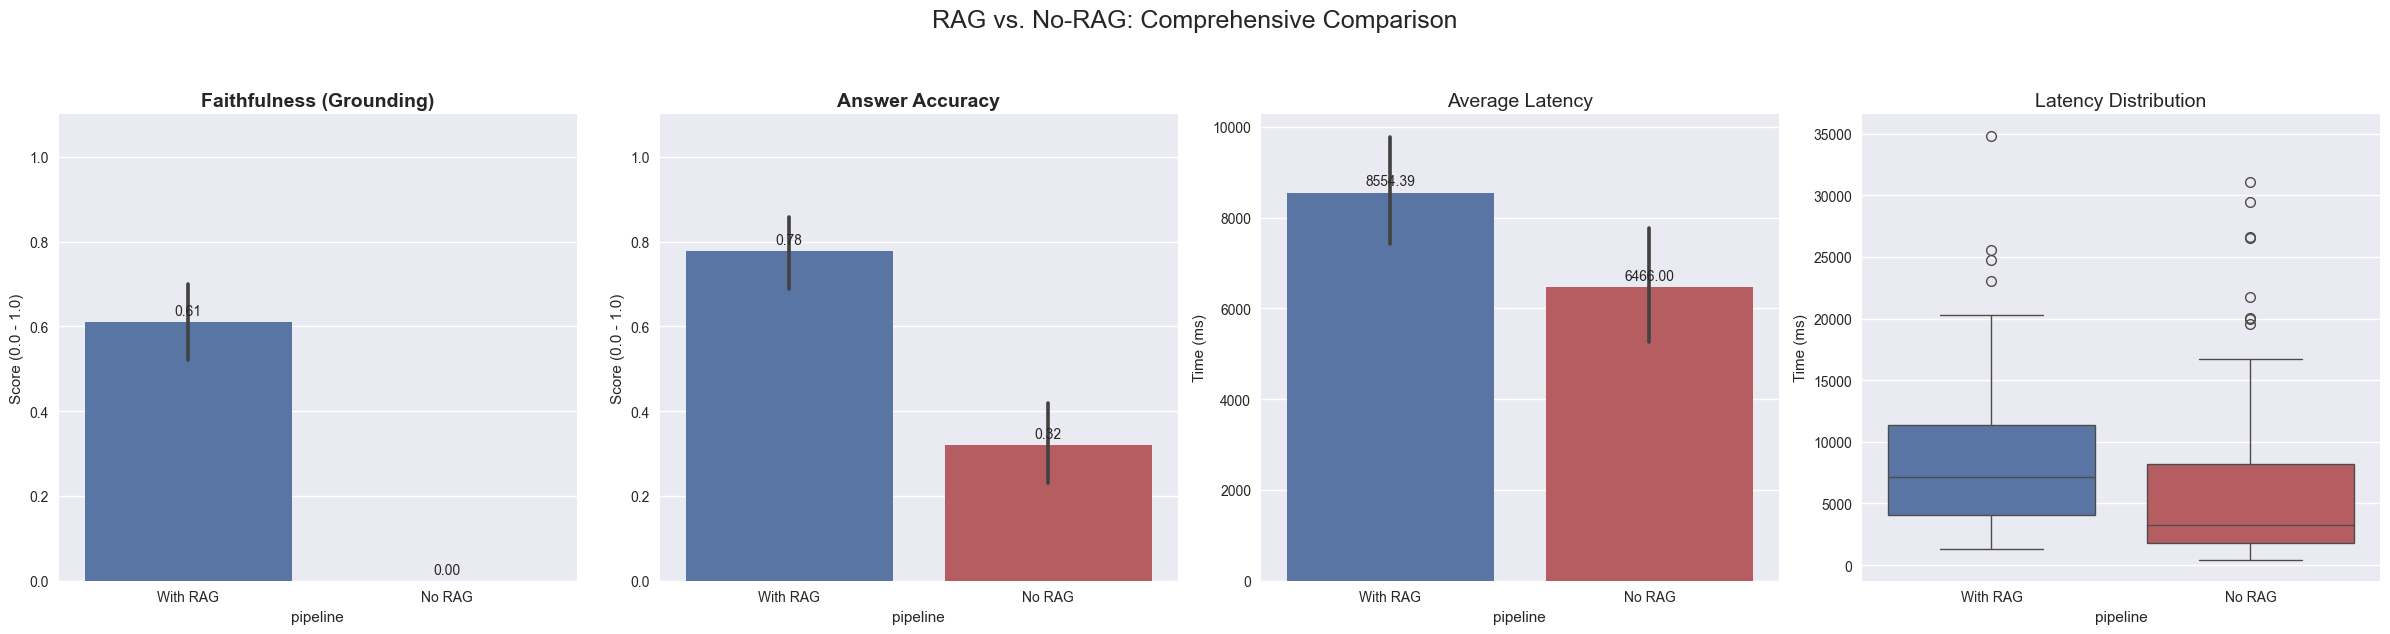

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_rag_comparison_extended(rag_df, no_rag_df):
    """
    Generates comparison plots including Faithfulness, Accuracy, and Latency.
    """
    # 1. Prepare Data
    rag_df = rag_df.copy()
    rag_df['pipeline'] = 'With RAG'
    
    no_rag_df = no_rag_df.copy()
    no_rag_df['pipeline'] = 'No RAG'
    
    combined_df = pd.concat([rag_df, no_rag_df], ignore_index=True)
    
    # 2. Setup Plotting
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(1, 4, figsize=(24, 6)) # Increased to 4 plots
    fig.suptitle('RAG vs. No-RAG: Comprehensive Comparison', fontsize=18, y=1.05)
    
    # Define colors
    colors = ['#4c72b0', '#c44e52']
    
    # --- Plot 1: Faithfulness (The Grounding Check) ---
    sns.barplot(
        data=combined_df, x='pipeline', y='faithfulness_score', 
        ax=axes[0], palette=colors, errorbar=('ci', 95)
    )
    axes[0].set_title('Faithfulness (Grounding)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Score (0.0 - 1.0)')
    axes[0].set_ylim(0, 1.1)
    
    # --- Plot 2: Accuracy (The Correctness Check) ---
    sns.barplot(
        data=combined_df, x='pipeline', y='accuracy_score', 
        ax=axes[1], palette=colors, errorbar=('ci', 95)
    )
    axes[1].set_title('Answer Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Score (0.0 - 1.0)')
    axes[1].set_ylim(0, 1.1)

    # --- Plot 3: Average Latency ---
    sns.barplot(
        data=combined_df, x='pipeline', y='total_latency_ms', 
        ax=axes[2], palette=colors
    )
    axes[2].set_title('Average Latency', fontsize=14)
    axes[2].set_ylabel('Time (ms)')
    
    # --- Plot 4: Latency Distribution ---
    sns.boxplot(
        data=combined_df, x='pipeline', y='total_latency_ms', 
        ax=axes[3], palette=colors
    )
    axes[3].set_title('Latency Distribution', fontsize=14)
    axes[3].set_ylabel('Time (ms)')
    
    # Add value labels to bar charts
    for ax in axes[:3]:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=3)

    plt.tight_layout()
    plt.show()

# Run the updated plot
if 'nq_results' in locals() and 'no_rag_results' in locals():
    plot_rag_comparison_extended(nq_results, no_rag_results)
else:
    print("⚠️ Missing data! Please ensure 'nq_results' and 'no_rag_results' are created.")

### Deep Dive Analysis
Visualize latency breakdowns, metric correlations, and score distributions for diagnostic purposes.

C:\Users\aamin\AppData\Local\Temp\ipykernel_25792\2582441389.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=melted_df, x='Metric', y='Score', ax=ax3,


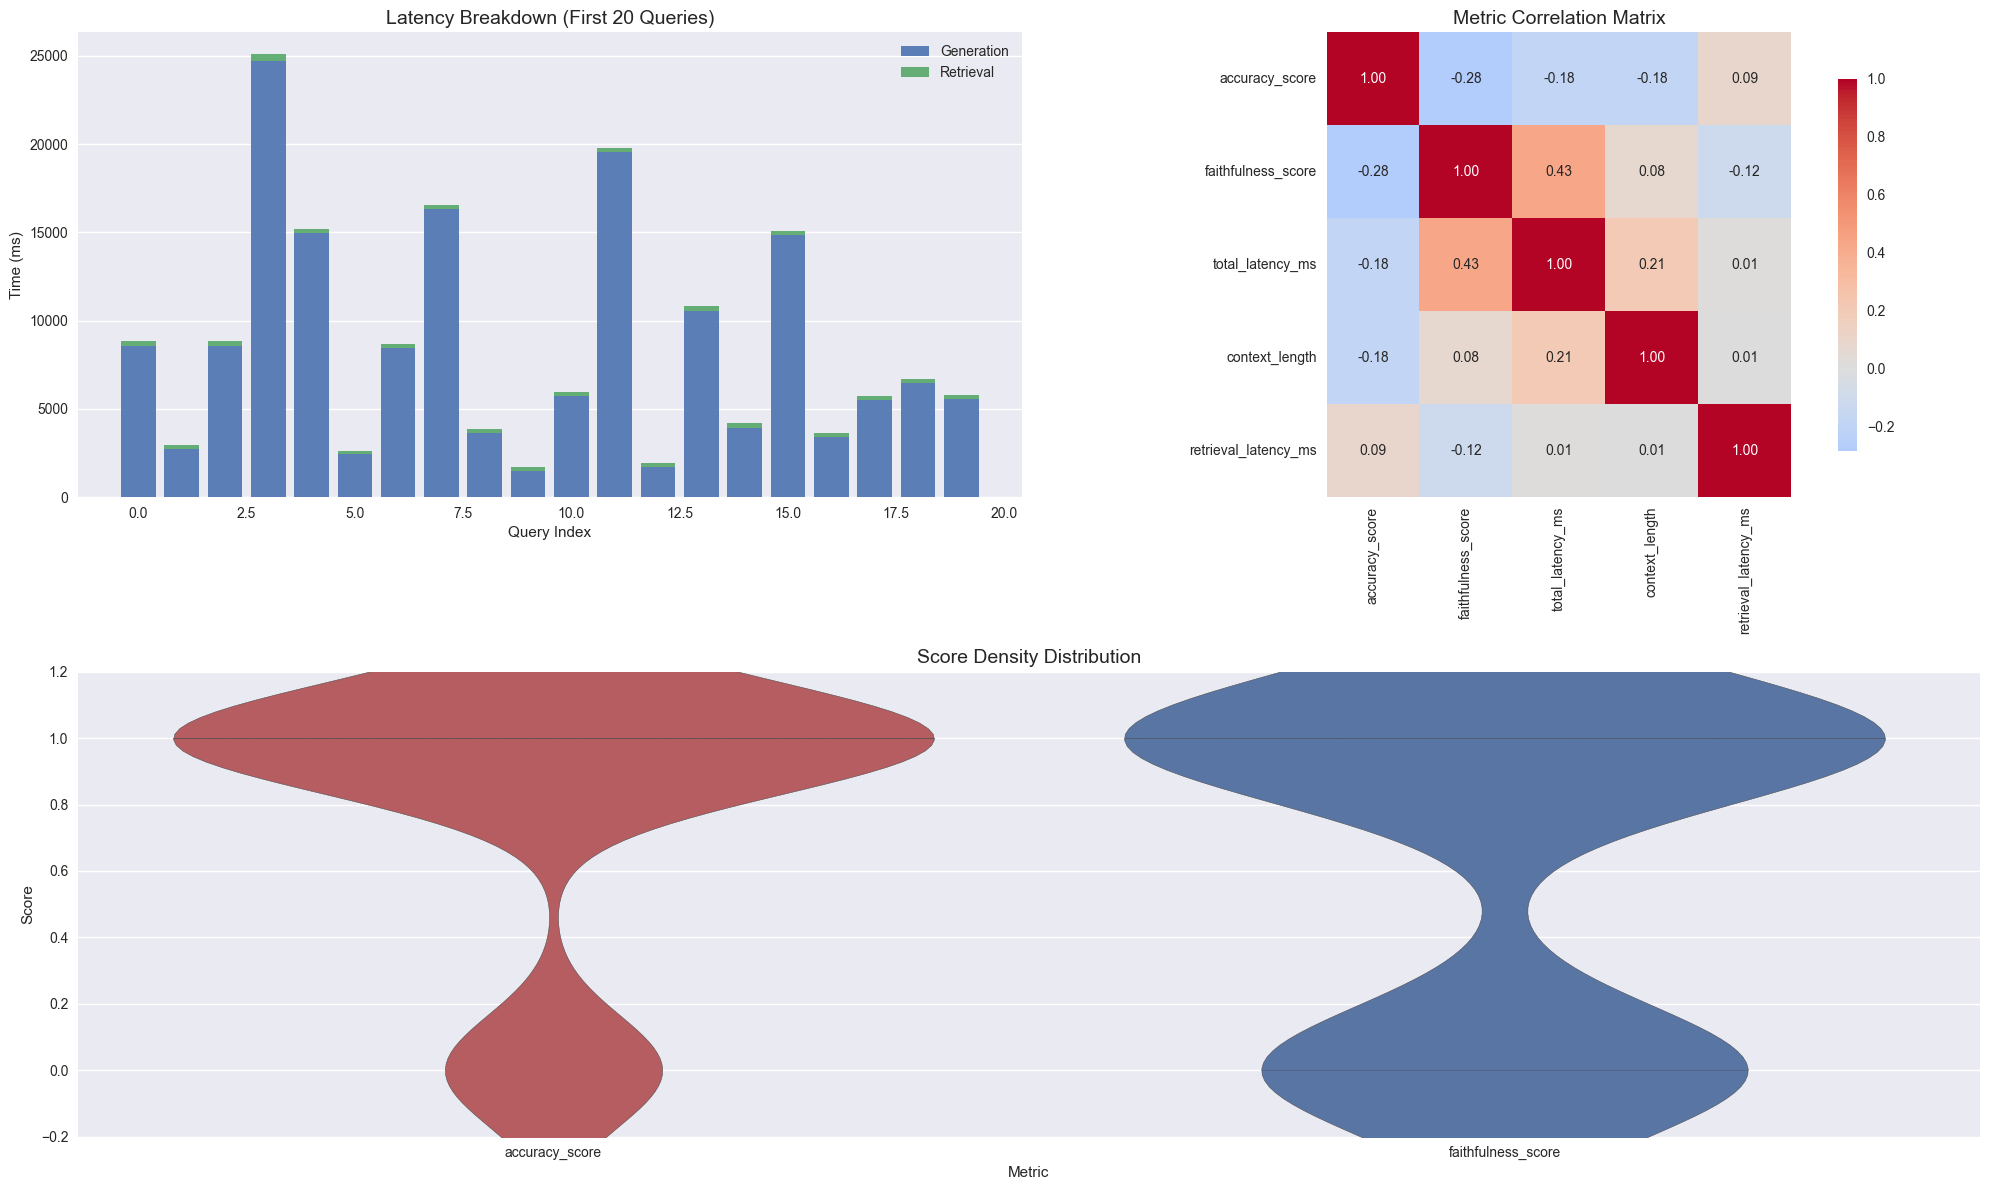

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_deep_dive_analysis(df):
    """
    Generates advanced visualizations for RAG diagnostics.
    """
    # Create a copy to avoid modifying original
    plot_df = df.copy()
    
    # 1. Feature Engineering: Calculate Context Length
    # (How many characters of text did we feed the LLM?)
    plot_df['context_length'] = plot_df['contexts'].apply(lambda x: len(str(x)))
    
    # Setup layout
    plt.style.use('seaborn-v0_8')
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 2)
    
    # --- Chart 1: Latency Breakdown (Stacked Bar) ---
    ax1 = fig.add_subplot(gs[0, 0])
    
    # Take a sample of 20 queries to keep the chart readable
    sample_df = plot_df.head(20).reset_index()
    
    # Plot Generation Time
    ax1.bar(sample_df.index, sample_df['generation_latency_ms'], 
            label='Generation', color='#4c72b0', alpha=0.9)
    
    # Plot Retrieval Time (Stacked on top)
    ax1.bar(sample_df.index, sample_df['retrieval_latency_ms'], 
            bottom=sample_df['generation_latency_ms'], 
            label='Retrieval', color='#55a868', alpha=0.9)
    
    ax1.set_title('Latency Breakdown (First 20 Queries)', fontsize=14)
    ax1.set_xlabel('Query Index')
    ax1.set_ylabel('Time (ms)')
    ax1.legend()
    ax1.grid(axis='x')

    # --- Chart 2: Correlation Heatmap ---
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Select numeric columns for correlation
    corr_cols = [
        'accuracy_score', 
        'faithfulness_score', 
        'total_latency_ms', 
        'context_length',
        'retrieval_latency_ms'
    ]
    
    # Calculate correlation matrix
    corr_matrix = plot_df[corr_cols].corr()
    
    # Draw heatmap
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, ax=ax2, cbar_kws={"shrink": .8})
    ax2.set_title('Metric Correlation Matrix', fontsize=14)

    # --- Chart 3: Metric Distributions (Violin Plot) ---
    ax3 = fig.add_subplot(gs[1, :]) # Spans entire bottom row
    
    # Melt dataframe for seaborn
    melted_df = plot_df.melt(
        value_vars=['accuracy_score', 'faithfulness_score'],
        var_name='Metric', value_name='Score'
    )
    
    sns.violinplot(data=melted_df, x='Metric', y='Score', ax=ax3, 
                   palette=['#c44e52', '#4c72b0'], inner='quartile')
    
    ax3.set_title('Score Density Distribution', fontsize=14)
    ax3.set_ylim(-0.2, 1.2) # Add some buffer space
    
    plt.tight_layout()
    plt.show()

# Run the analysis
if 'nq_results' in locals():
    # Ensure faithfulness exists (if you ran the previous step)
    if 'faithfulness_score' not in nq_results.columns:
        print("⚠️ 'faithfulness_score' missing. Filling with 0 for demo purposes.")
        nq_results['faithfulness_score'] = 0
        
    plot_deep_dive_analysis(nq_results)
else:
    print("⚠️ Please ensure 'nq_results' dataframe is available.")

### Search Method Comparison Wrappers
Define standardized wrappers for BM25, Semantic, Hybrid, and Reranking search methods.

In [ ]:
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Wrappers to make all functions interchangeable
def search_bm25(query, collection, top_k=5):
    response = collection.query.bm25(query=query, limit=top_k)
    return [o.properties for o in response.objects]

def search_semantic(query, collection, top_k=5):
    response = collection.query.near_text(query=query, limit=top_k)
    return [o.properties for o in response.objects]

def search_hybrid(query, collection, top_k=5):
    # Alpha=0.5 balances keyword and vector search equally
    response = collection.query.hybrid(query=query, limit=top_k, alpha=0.5)
    return [o.properties for o in response.objects]

def search_reranking(query, collection, top_k=5):
    # Retrieve more docs (e.g., 20) then select top_k (e.g., 5)
    response = collection.query.near_text(
        query=query, 
        limit=top_k,
        rerank=Rerank(prop="answer", query=query) # Reranking based on answer content
    )
    return [o.properties for o in response.objects]

# Dictionary mapping names to functions
SEARCH_METHODS = {
    "BM25": search_bm25,
    "Semantic": search_semantic,
    "Hybrid": search_hybrid,
    "Reranking": search_reranking
}

### LLM-Based Metric Calculation
Use an LLM to grade relevance and faithfulness on a binary scale.

In [ ]:
def calculate_metrics(query, context, response):
    """
    Uses the LLM to grade Faithfulness and Relevance on a scale of 0 or 1.
    """
    
    # 1. Relevance: Is the retrieved context actually helpful for the query?
    rel_prompt = f"""
    Query: {query}
    Retrieved Context: {context}
    
    Is the information in the retrieved context relevant to answering the query? 
    Respond ONLY with 'YES' or 'NO'.
    """
    rel_response = generate_with_single_input(rel_prompt, model="meta-llama/llama-3.2-3b-instruct")['content']
    relevance_score = 1.0 if "YES" in rel_response.upper() else 0.0

    # 2. Faithfulness: Is the answer derived *only* from the context?
    faith_prompt = f"""
    Context: {context}
    Answer: {response}
    
    Is the answer purely supported by the context provided? 
    Respond ONLY with 'YES' or 'NO'.
    """
    faith_response = generate_with_single_input(faith_prompt, model="meta-llama/llama-3.2-3b-instruct")['content']
    faithfulness_score = 1.0 if "YES" in faith_response.upper() else 0.0
    
    return relevance_score, faithfulness_score

### Automated Evaluation Sampling
Sample valid Q&A pairs from the dataset and format them for the automated evaluation loop.

In [ ]:
import numpy as np
import random

def is_valid_entry(p):
    """Safely checks if the pair has valid answer data (handles arrays/lists/strings)."""
    ans = p.get('answers')
    
    # 1. Handle NumPy Arrays (The cause of your error)
    if isinstance(ans, np.ndarray):
        return ans.size > 0
        
    # 2. Handle Python Lists
    if isinstance(ans, list):
        return len(ans) > 0
        
    # 3. Handle Strings
    if isinstance(ans, str):
        return ans and ans != "No data provided"
        
    return False

def get_clean_truth(ans):
    """Extracts the first valid answer string from any format."""
    if isinstance(ans, np.ndarray):
        return str(ans[0]) if ans.size > 0 else "N/A"
    elif isinstance(ans, list):
        return str(ans[0]) if len(ans) > 0 else "N/A"
    elif isinstance(ans, str):
        # Split by common delimiters just in case
        return ans.split(';')[0].split(',')[0].strip()
    return str(ans)

# --- Main Execution ---

# 1. Filter safely using the helper function
valid_pairs = [p for p in nq_qa_pairs if is_valid_entry(p)]

# 2. Select 20 random samples
random_samples = random.sample(valid_pairs, 20)

# 3. Format for your evaluation loop
automated_eval_data = []
for item in random_samples:
    truth = get_clean_truth(item['answers'])
    
    automated_eval_data.append({
        "query": item['question'],
        "ground_truth": truth
    })

# 4. Add to your main eval_data list
# eval_data.extend(automated_eval_data)

print(f"Successfully sampled {len(automated_eval_data)} queries.")
print("Example:", automated_eval_data[0])

Successfully sampled 20 queries.
Example: {'query': 'what kind of money do they use in russia', 'ground_truth': 'ruble'}


### Run Multi-Method Evaluation
Execute comprehensive evaluation across all search methods and calculate average metrics.

In [ ]:
def run_evaluation(test_queries, collection, methods=SEARCH_METHODS):
    results = []
    
    print(f"Starting evaluation on {len(test_queries)} queries...")
    
    for method_name, search_func in methods.items():
        print(f"Evaluating {method_name}...")
        
        for q_idx, item in enumerate(test_queries):
            query = item['query']
            ground_truth = item.get('ground_truth', 'N/A')
            
            # --- 1. Measure Latency ---
            start_time = time.time()
            
            # Retrieve
            retrieved_docs = search_func(query, collection, top_k=5)
            
            # Format Context
            context_text = "\n".join([f"A: {doc['answer']}" for doc in retrieved_docs])
            
            # Generate Answer (RAG)
            prompt = f"Context: {context_text}\n\nQuestion: {query}\nAnswer:"
            llm_response = generate_with_single_input(prompt, model="meta-llama/llama-3.2-3b-instruct")['content']
            
            end_time = time.time()
            latency = (end_time - start_time)
            
            # --- 2. Calculate Quality Metrics ---
            relevance, faithfulness = calculate_metrics(query, context_text, llm_response)
            
            results.append({
                "Method": method_name,
                "Query": query,
                "Latency (s)": latency,
                "Relevance": relevance,
                "Faithfulness": faithfulness,
                "Response Length": len(llm_response)
            })
            
    return pd.DataFrame(results)

# --- Define Evaluation Data ---
# You can use a subset of your NQ data
eval_data = []
eval_data.extend(automated_eval_data)
# --- Run the Evaluation ---
df_results = run_evaluation(eval_data, collection)

# Display average metrics
print("\n=== Average Metrics by Method ===")
print(df_results.groupby("Method")[["Latency (s)", "Relevance", "Faithfulness"]].mean())

Starting evaluation on 20 queries...
Evaluating BM25...
Evaluating Semantic...
Evaluating Hybrid...
Evaluating Reranking...

=== Average Metrics by Method ===
           Latency (s)  Relevance  Faithfulness
Method                                         
BM25          1.717405       0.40          0.00
Hybrid        2.158634       0.25          0.00
Reranking     2.013290       0.25          0.00
Semantic      2.759491       0.35          0.15


### Final Visualization: Method Comparison
Generate comparison plots for latency, relevance, and faithfulness across all retrieval strategies.

C:\Users\aamin\AppData\Local\Temp\ipykernel_25792\2864816314.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="Latency (s)", data=df, palette="viridis")
C:\Users\aamin\AppData\Local\Temp\ipykernel_25792\2864816314.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="Relevance", data=df, palette="rocket")
C:\Users\aamin\AppData\Local\Temp\ipykernel_25792\2864816314.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Method", y="Faithfulness", data=df, palette="mako")


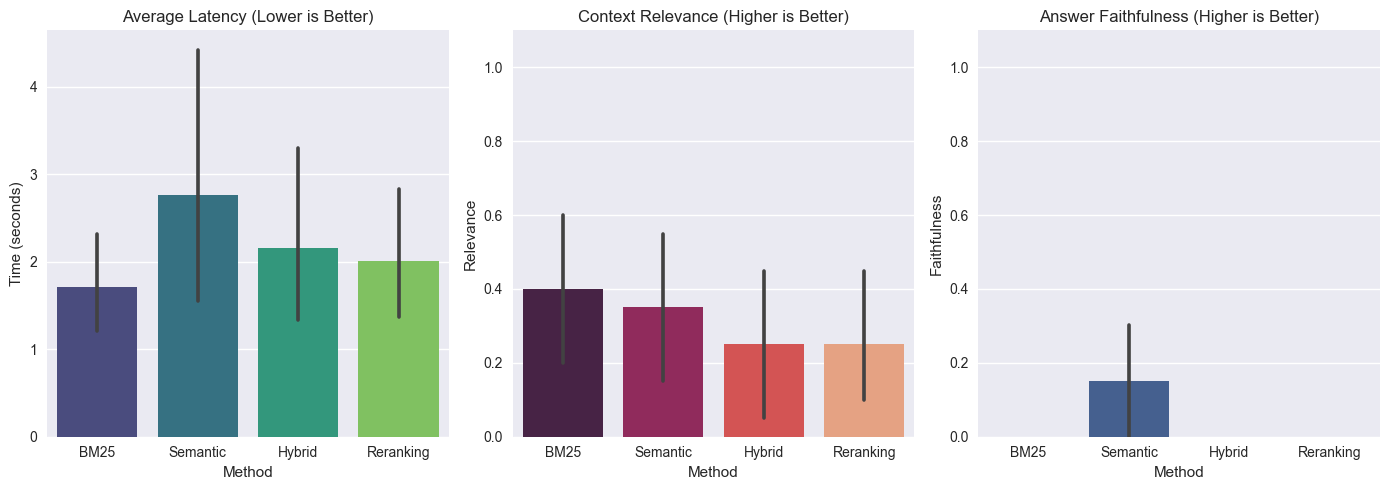

In [ ]:
def plot_results(df):
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Latency Comparison
    plt.subplot(1, 3, 1)
    sns.barplot(x="Method", y="Latency (s)", data=df, palette="viridis")
    plt.title("Average Latency (Lower is Better)")
    plt.ylabel("Time (seconds)")
    
    # Plot 2: Relevance Score
    plt.subplot(1, 3, 2)
    sns.barplot(x="Method", y="Relevance", data=df, palette="rocket")
    plt.title("Context Relevance (Higher is Better)")
    plt.ylim(0, 1.1)
    
    # Plot 3: Faithfulness Score
    plt.subplot(1, 3, 3)
    sns.barplot(x="Method", y="Faithfulness", data=df, palette="mako")
    plt.title("Answer Faithfulness (Higher is Better)")
    plt.ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

plot_results(df_results)